# 🦷 Dental X-Ray Detection: YOLOv26m — Kaggle
Trains **YOLOv26m** (latest state-of-the-art model) on balanced **Dataset 2**.


## 1. 🖥️ Kaggle Environment Setup

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 0: Kaggle Environment Setup
# Verifies input dataset paths and creates the working output directory.
# ─────────────────────────────────────────────────────────────────────────────
import os

KAGGLE_INPUT  = '/kaggle/input'
KAGGLE_OUTPUT = '/kaggle/working'

print('📂 Available Kaggle input datasets:')
if os.path.isdir(KAGGLE_INPUT):
    for ds in sorted(os.listdir(KAGGLE_INPUT)):
        ds_path = os.path.join(KAGGLE_INPUT, ds)
        n_files = sum(len(files) for _, _, files in os.walk(ds_path))
        print(f'   {ds}  ({n_files} files)')
else:
    print(f'   ⚠️  {KAGGLE_INPUT} not found – are you running on Kaggle?')

os.makedirs(KAGGLE_OUTPUT, exist_ok=True)
print(f'\n✅ Output directory ready: {KAGGLE_OUTPUT}')
print('\n💡 Tip: Update DATASET2_PATH in Cell 3 (Config) to match your')
print('        Kaggle dataset slug shown above if needed.')

📂 Available Kaggle input datasets:
   datasets  (2155 files)

✅ Output directory ready: /kaggle/working

💡 Tip: Update DATASET2_PATH in Cell 3 (Config) to match your
        Kaggle dataset slug shown above if needed.


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# GPU Info — verify accelerator is active before training
# ─────────────────────────────────────────────────────────────────────────────
import subprocess

try:
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=index,name,memory.total,memory.free,temperature.gpu',
         '--format=csv,noheader,nounits'],
        capture_output=True, text=True, check=True
    )
    print('📊 nvidia-smi GPU Report:')
    print(f'  {"GPU":>4}  {"Name":<25}  {"Total VRAM":>10}  {"Free VRAM":>10}  {"Temp °C":>8}')
    print('  ' + '─' * 65)
    for line in result.stdout.strip().split('\n'):
        idx, name, total, free, temp = [x.strip() for x in line.split(',')]
        print(f'  {idx:>4}  {name:<25}  {int(total)/1024:>8.1f} GB  {int(free)/1024:>8.1f} GB  {temp:>7}°C')
except Exception as e:
    print(f'nvidia-smi not available: {e}')

import torch
print(f'\n🔦 torch.cuda.device_count() = {torch.cuda.device_count()}')
print(f'   CUDA available             = {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   Current device             = cuda:{torch.cuda.current_device()}')
    print(f'   GPU Name                   = {torch.cuda.get_device_name(0)}')

📊 nvidia-smi GPU Report:
   GPU  Name                       Total VRAM   Free VRAM   Temp °C
  ─────────────────────────────────────────────────────────────────
     0  Tesla T4                       15.0 GB      14.6 GB       34°C
     1  Tesla T4                       15.0 GB      14.6 GB       39°C

🔦 torch.cuda.device_count() = 2
   CUDA available             = True
   Current device             = cuda:0
   GPU Name                   = Tesla T4


## 2. 📦 Install Dependencies

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 1: Install Ultralytics and supporting packages
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, sys
def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])
# Install ultralytics & albumentations
pip_install('ultralytics>=8.3.0', 'albumentations>=1.4.0')
pip_install(
    'pyyaml', 'tqdm', 'matplotlib', 'seaborn', 'pandas',
    'scikit-learn', 'plotly', 'kaleido', 'pillow', 'opencv-python'
)
print('👍 All dependencies installed.')
from ultralytics import YOLO
import ultralytics
print(f'Ultralytics version: {ultralytics.__version__}')


👍 All dependencies installed.
Ultralytics version: 8.4.64


## 3. ⚙️ Configuration

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 2: Central config  ← edit here to tune training
# ─────────────────────────────────────────────────────────────────────────────
from pathlib import Path
import os
CFG = {
    # ── Paths ──────────────────────────────────────────────────────────────
    'dataset2_path': '/kaggle/input/datasets/kerolossoliman/dental-xray-yolo26',
    'output_dir':    '/kaggle/working/yolov26_m_outputs',
    # ── Classes (no background for YOLO) ───────────────────────────────────
    'classes': ['Cavity', 'Fillings', 'Impacted Tooth', 'Implant'],
    # ── YOLOv26 variants to train ───────────────────────────────────────────
    # Each entry: (model_name, weights_file, run_name)
    'variants': [
        ('YOLOv26m', 'yolo26m.pt', 'dental_yolov26m'),
    ],
    # ── Training hyperparameters ────────────────────────────────────────────
    'image_size':    640,
    'batch_size':    16,
    'num_epochs':    150,
    'lr0':           1e-3,
    'lrf':           0.01,
    'momentum':      0.937,
    'weight_decay':  5e-4,
    'warmup_epochs': 3,
    'patience':      20,
    'workers':       4,
    # ── Augmentation ────────────────────────────────────────────────────────
    'hsv_h':   0.015,
    'hsv_s':   0.7,
    'hsv_v':   0.4,
    'degrees':  10.0,
    'translate': 0.1,
    'scale':    0.5,
    'flipud':   0.1,
    'fliplr':   0.5,
    'mosaic':   1.0,
    'mixup':    0.2,
    'copy_paste': 0.1,
    # ── Inference thresholds ────────────────────────────────────────────────
    'conf_threshold': 0.25,
    'iou_threshold':  0.45,
    # ── Device ──────────────────────────────────────────────────────────────
    'device': '0',
}
os.makedirs(CFG['output_dir'], exist_ok=True)
print('📁 Output directory:', CFG['output_dir'])
print(f"   image_size={CFG['image_size']}  batch={CFG['batch_size']}")
print(f"   epochs={CFG['num_epochs']}  patience={CFG['patience']}")
print(f"\n🏋️  Variants to train:")
for name, weights, run in CFG['variants']:
    print(f'   {name} → {weights} (run: {run})')


📁 Output directory: /kaggle/working/yolov26_m_outputs
   image_size=640  batch=16
   epochs=150  patience=20

🏋️  Variants to train:
   YOLOv26m → yolo26m.pt (run: dental_yolov26m)


## 4. 📁 Prepare data.yaml

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 3: Locate dataset & write/verify data.yaml for Ultralytics
# ─────────────────────────────────────────────────────────────────────────────
import yaml
from pathlib import Path
root = Path(CFG['dataset2_path'])
SPLIT_ALIASES = {
    'train': ['train', 'training', 'Train'],
    'val':   ['val', 'valid', 'validation', 'Val'],
    'test':  ['test', 'testing', 'Test'],
}
def find_split(root: Path, split: str) -> Path:
    for alias in SPLIT_ALIASES.get(split, [split]):
        p = root / alias / 'images'
        if p.is_dir():
            return p
        p2 = root / alias
        if p2.is_dir():
            return p2
    raise FileNotFoundError(f"Cannot find '{split}' split under {root}")
train_dir = find_split(root, 'train')
val_dir   = find_split(root, 'val')
try:
    test_dir = find_split(root, 'test')
    has_test = True
except FileNotFoundError:
    test_dir = None
    has_test = False
print(f'📊 train → {train_dir}')
print(f'📊 val   → {val_dir}')
print(f'📊 test  → {test_dir if has_test else "(not found)"}')
# Initial data.yaml path
data_yaml_path = Path(CFG['output_dir']) / 'data.yaml'
data_yaml = {
    'path':  str(root),
    'train': str(train_dir),
    'val':   str(val_dir),
    'nc':    len(CFG['classes']),
    'names': CFG['classes'],
}
if has_test:
    data_yaml['test'] = str(test_dir)
with open(data_yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)
print(f'\n📂 data.yaml ready at {data_yaml_path}')


📊 train → /kaggle/input/datasets/kerolossoliman/dental-xray-yolo26/train/images
📊 val   → /kaggle/input/datasets/kerolossoliman/dental-xray-yolo26/valid/images
📊 test  → /kaggle/input/datasets/kerolossoliman/dental-xray-yolo26/test/images

📂 data.yaml ready at /kaggle/working/yolov26_m_outputs/data.yaml


⚡ Copying original dataset to /kaggle/working/balanced_dataset...

📈 Class counts before augmentation:
  Cavity: 398
  Fillings: 3692
  Impacted Tooth: 316
  Implant: 1225

🔄 Starting data augmentation for balancing...
  Class 'Cavity': augmenting to add 1602 instances...


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


  Class 'Fillings' already has 6837 instances. Skipping augmentation.
  Class 'Impacted Tooth': augmenting to add 1521 instances...
  Class 'Implant' already has 2897 instances. Skipping augmentation.

🎯 Class counts after augmentation:
  Cavity: 2364
  Fillings: 8641
  Impacted Tooth: 2001
  Implant: 2897

Created balanced data.yaml at: /kaggle/working/balanced_dataset/data.yaml


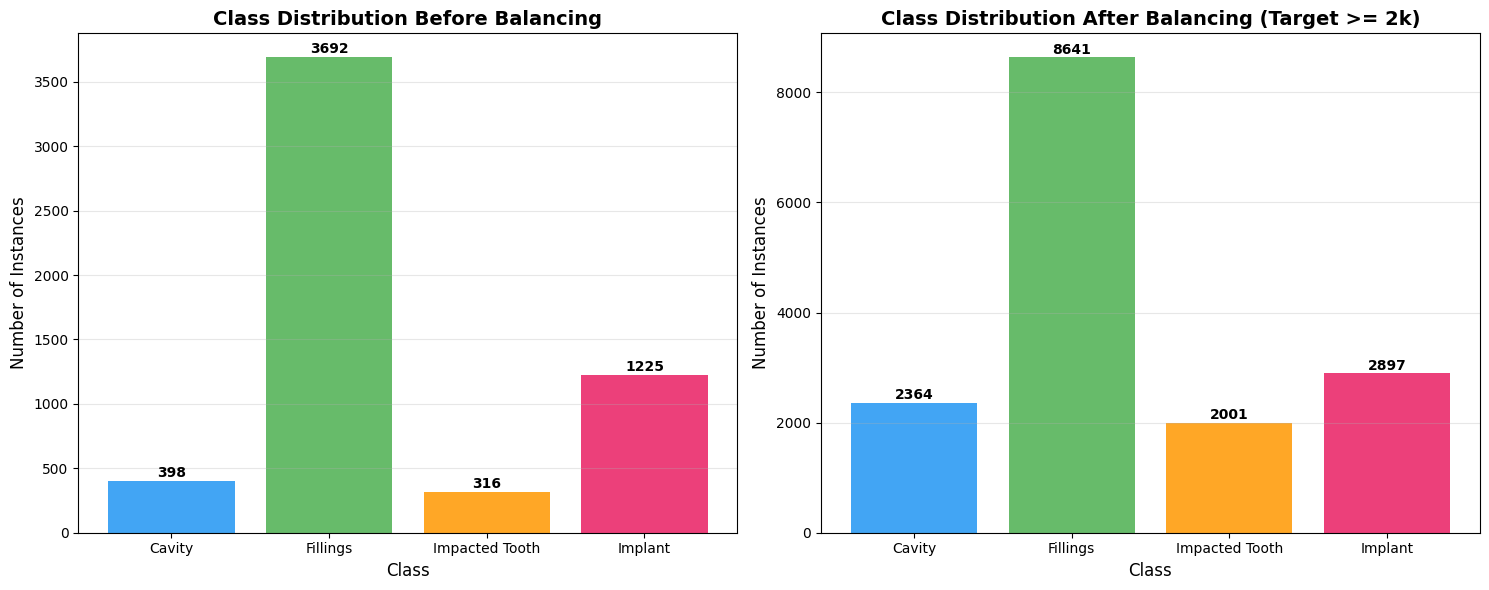

Saved distribution comparison plot to: /kaggle/working/yolov26_m_outputs/class_distribution.png


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 4: Dataset class distribution analysis & On-The-Fly Augmentation
# ─────────────────────────────────────────────────────────────────────────────
import os
import shutil
import random
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import albumentations as A
# 1. Paths
original_root = Path(CFG['dataset2_path'])
balanced_root = Path('/kaggle/working/balanced_dataset')
# Remove if exists to start fresh
if balanced_root.exists():
    shutil.rmtree(balanced_root)
# Recreate folders
train_img_dir = balanced_root / 'train' / 'images'
train_lbl_dir = balanced_root / 'train' / 'labels'
val_img_dir = balanced_root / 'valid' / 'images'
val_lbl_dir = balanced_root / 'valid' / 'labels'
os.makedirs(train_img_dir, exist_ok=True)
os.makedirs(train_lbl_dir, exist_ok=True)
os.makedirs(val_img_dir, exist_ok=True)
os.makedirs(val_lbl_dir, exist_ok=True)
# Copy original train & val images/labels
print("⚡ Copying original dataset to /kaggle/working/balanced_dataset...")
shutil.copytree(original_root / 'train' / 'images', train_img_dir, dirs_exist_ok=True)
shutil.copytree(original_root / 'train' / 'labels', train_lbl_dir, dirs_exist_ok=True)
shutil.copytree(original_root / 'valid' / 'images', val_img_dir, dirs_exist_ok=True)
shutil.copytree(original_root / 'valid' / 'labels', val_lbl_dir, dirs_exist_ok=True)
# Test split (optional)
has_test = False
test_img_dir = balanced_root / 'test' / 'images'
test_lbl_dir = balanced_root / 'test' / 'labels'
if (original_root / 'test').exists():
    os.makedirs(test_img_dir, exist_ok=True)
    os.makedirs(test_lbl_dir, exist_ok=True)
    shutil.copytree(original_root / 'test' / 'images', test_img_dir, dirs_exist_ok=True)
    shutil.copytree(original_root / 'test' / 'labels', test_lbl_dir, dirs_exist_ok=True)
    has_test = True
elif (original_root / 'valid').exists():
    # If no test split, use validation split as test split fallback
    os.makedirs(test_img_dir, exist_ok=True)
    os.makedirs(test_lbl_dir, exist_ok=True)
    shutil.copytree(original_root / 'valid' / 'images', test_img_dir, dirs_exist_ok=True)
    shutil.copytree(original_root / 'valid' / 'labels', test_lbl_dir, dirs_exist_ok=True)
    has_test = True
# Helper to count instances
def count_instances(labels_dir):
    counts = Counter()
    for lbl_file in Path(labels_dir).glob('*.txt'):
        with open(lbl_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[int(float(parts[0]))] += 1
    return counts
# Class counts before augmentation
before_counts = count_instances(train_lbl_dir)
print("\n📈 Class counts before augmentation:")
for i, name in enumerate(CFG['classes']):
    print(f"  {name}: {before_counts[i]}")
# 2. Perform augmentation to balance all classes to 2000 instances
# Group files by classes they contain
label_files = list(train_lbl_dir.glob('*.txt'))
class_to_files = {i: [] for i in range(len(CFG['classes']))}
for lf in label_files:
    classes_in_file = set()
    with open(lf, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                classes_in_file.add(int(parts[0]))
    for c in classes_in_file:
        class_to_files[c].append(lf)
# Albumentations transform
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, border_mode=0, p=0.5),
    A.GaussNoise(p=0.2),
], bbox_params=A.BboxParams(clip='True', min_area=1, min_visibility=0.1, format='yolo', label_fields=['class_labels']))
def read_yolo_labels(path):
    bboxes = []
    labels = []
    with open(path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                labels.append(int(float(parts[0])))
                x_c = max(0.0, min(1.0, float(parts[1])))
                y_c = max(0.0, min(1.0, float(parts[2])))
                w   = max(0.0, min(1.0, float(parts[3])))
                h   = max(0.0, min(1.0, float(parts[4])))
                bboxes.append([float(x) for x in parts[1:5]])
    return bboxes, labels
def write_yolo_labels(path, bboxes, labels):
    with open(path, 'w') as f:
        for bbox, label in zip(bboxes, labels):
            f.write(f"{label} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")
# Copy before counts
current_counts = Counter(before_counts)
print("\n🔄 Starting data augmentation for balancing...")
for c in range(len(CFG['classes'])):
    needed = 2000 - current_counts[c]
    if needed <= 0:
        print(f"  Class '{CFG['classes'][c]}' already has {current_counts[c]} instances. Skipping augmentation.")
        continue
    
    candidates = class_to_files[c]
    if not candidates:
        print(f"  Warning: No images found containing class '{CFG['classes'][c]}'. Cannot augment.")
        continue
    
    print(f"  Class '{CFG['classes'][c]}': augmenting to add {needed} instances...")
    aug_idx = 0
    while needed > 0:
        lbl_file = random.choice(candidates)
        img_file = None
        for ext in ['.jpg', '.jpeg', '.png']:
            candidate_img = train_img_dir / f"{lbl_file.stem}{ext}"
            if candidate_img.exists():
                img_file = candidate_img
                break
        
        if img_file is None:
            continue
            
        image = cv2.imread(str(img_file))
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        bboxes, labels = read_yolo_labels(lbl_file)
        if not bboxes:
            continue
            
        try:
            augmented = transform(image=image, bboxes=bboxes, class_labels=labels)
            aug_img = augmented['image']
            aug_bboxes = augmented['bboxes']
            aug_labels = augmented['class_labels']
        except Exception:
            continue
            
        if not aug_bboxes:
            continue
            
        new_stem = f"{img_file.stem}_aug_class{c}_{aug_idx}"
        new_img_path = train_img_dir / f"{new_stem}.jpg"
        new_lbl_path = train_lbl_dir / f"{new_stem}.txt"
        
        cv2.imwrite(str(new_img_path), cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))
        write_yolo_labels(new_lbl_path, aug_bboxes, aug_labels)
        
        for l in aug_labels:
            current_counts[l] += 1
            if l == c:
                needed -= 1
        
        aug_idx += 1
# Class counts after augmentation
after_counts = count_instances(train_lbl_dir)
print("\n🎯 Class counts after augmentation:")
for i, name in enumerate(CFG['classes']):
    print(f"  {name}: {after_counts[i]}")
# Write updated data.yaml
balanced_yaml = {
    'path': str(balanced_root),
    'train': 'train/images',
    'val': 'valid/images',
    'nc': len(CFG['classes']),
    'names': CFG['classes']
}
if has_test:
    balanced_yaml['test'] = 'test/images'
data_yaml_path = balanced_root / 'data.yaml'
with open(data_yaml_path, 'w') as f:
    yaml.dump(balanced_yaml, f)
print(f"\nCreated balanced data.yaml at: {data_yaml_path}")
# Plot Before and After Distributions
classes = CFG['classes']
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
# Before
vals_before = [before_counts[i] for i in range(len(classes))]
bars_before = axes[0].bar(classes, vals_before, color=colors, alpha=0.85)
axes[0].set_title('Class Distribution Before Balancing', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Instances', fontsize=12)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars_before, vals_before):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
# After
vals_after = [after_counts[i] for i in range(len(classes))]
bars_after = axes[1].bar(classes, vals_after, color=colors, alpha=0.85)
axes[1].set_title('Class Distribution After Balancing (Target >= 2k)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Instances', fontsize=12)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars_after, vals_after):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
dist_chart_path = Path(CFG['output_dir']) / 'class_distribution.png'
plt.savefig(dist_chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved distribution comparison plot to: {dist_chart_path}")


## 5. 🏋️ Train YOLOv26m


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 5: Training loop — trains all 4 variants sequentially
#
# Results are saved under:
#   /kaggle/working/yolov8_outputs/<run_name>/
#       weights/best.pt
#       weights/last.pt
#       results.csv
#       confusion_matrix.png
#       F1_curve.png  PR_curve.png  etc.
# ─────────────────────────────────────────────────────────────────────────────
import time
from ultralytics import YOLO

training_results = {}   # store YOLO result objects keyed by variant name

for variant_name, weights_file, run_name in CFG['variants']:
    print('\n' + '═'*70)
    print(f'  🚀  Training {variant_name}  (weights: {weights_file})')
    print('═'*70)

    model = YOLO(weights_file)   # downloads pretrained weights on first run

    t0 = time.time()
    results = model.train(
        data        = str(data_yaml_path),
        epochs      = CFG['num_epochs'],
        imgsz       = CFG['image_size'],
        batch       = CFG['batch_size'],
        lr0         = CFG['lr0'],
        lrf         = CFG['lrf'],
        momentum    = CFG['momentum'],
        weight_decay= CFG['weight_decay'],
        warmup_epochs= CFG['warmup_epochs'],
        patience    = CFG['patience'],
        workers     = CFG['workers'],
        device      = CFG['device'],
        project     = CFG['output_dir'],
        name        = run_name,
        exist_ok    = True,        # don't fail if run_name already exists
        pretrained  = True,
        optimizer   = 'AdamW',
        # Augmentation
        hsv_h       = CFG['hsv_h'],
        hsv_s       = CFG['hsv_s'],
        hsv_v       = CFG['hsv_v'],
        degrees     = CFG['degrees'],
        translate   = CFG['translate'],
        scale       = CFG['scale'],
        flipud      = CFG['flipud'],
        fliplr      = CFG['fliplr'],
        mosaic      = CFG['mosaic'],
        mixup       = CFG['mixup'],
        copy_paste  = CFG['copy_paste'],
        # Confidence / NMS
        conf        = CFG['conf_threshold'],
        iou         = CFG['iou_threshold'],
        # Verbosity
        verbose     = True,
        save        = True,
        save_period = 10,   # save checkpoint every 10 epochs
        plots       = True,
    )
    elapsed = time.time() - t0
    training_results[variant_name] = results

    print(f'\n✅ {variant_name} training complete in {elapsed/60:.1f} min')
    best_map = getattr(results, 'results_dict', {}).get('metrics/mAP50(B)', 'N/A')
    print(f'   Best mAP@0.5 = {best_map}')

print('\n🎉 All variants trained successfully!')


══════════════════════════════════════════════════════════════════════
  🚀  Training YOLOv26m  (weights: yolo26m.pt)
══════════════════════════════════════════════════════════════════════
Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=0.25, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/balanced_dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.45, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_

## 6. 📊 Evaluation & Comparison

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 6: Validate all models on val set and collect metrics
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd

metrics_rows = []

for variant_name, weights_file, run_name in CFG['variants']:
    best_weights = Path(CFG['output_dir']) / run_name / 'weights' / 'best.pt'
    if not best_weights.exists():
        print(f'⚠️  {variant_name}: best.pt not found at {best_weights}')
        continue

    print(f'\n🔍 Validating {variant_name}...')
    model = YOLO(str(best_weights))
    val_results = model.val(
        data    = str(data_yaml_path),
        imgsz   = CFG['image_size'],
        batch   = CFG['batch_size'],
        device  = CFG['device'],
        project = CFG['output_dir'],
        name    = f'{run_name}_val',
        exist_ok= True,
        conf    = CFG['conf_threshold'],
        iou     = CFG['iou_threshold'],
        verbose = False,
    )

    rd = val_results.results_dict if hasattr(val_results, 'results_dict') else {}
    metrics_rows.append({
        'Variant':         variant_name,
        'mAP@0.5':         round(rd.get('metrics/mAP50(B)',    0), 4),
        'mAP@0.5:0.95':    round(rd.get('metrics/mAP50-95(B)', 0), 4),
        'Precision':       round(rd.get('metrics/precision(B)', 0), 4),
        'Recall':          round(rd.get('metrics/recall(B)',    0), 4),
        'Weights':         str(best_weights),
    })
    print(f'   mAP@0.5={rd.get("metrics/mAP50(B)", "N/A"):.4f}  '
          f'mAP@0.5:0.95={rd.get("metrics/mAP50-95(B)", "N/A"):.4f}')

metrics_df = pd.DataFrame(metrics_rows)
print('\n' + '═'*65)
print('  📋 Validation Metrics — All YOLOv8 Variants')
print('═'*65)
print(metrics_df.to_string(index=False))

# Save to CSV
metrics_csv = Path(CFG['output_dir']) / 'all_variants_metrics.csv'
metrics_df.to_csv(metrics_csv, index=False)
print(f'\n✅ Metrics saved to {metrics_csv}')


🔍 Validating YOLOv26m...
Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,352,536 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1056.3±259.8 MB/s, size: 32.3 KB)
val: Scanning /kaggle/working/balanced_dataset/valid/labels.cache... 215 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 215/215 90.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 1.7it/s 8.1s0.6s
                   all        215       1657      0.918      0.904      0.908      0.698
Speed: 1.9ms preprocess, 30.6ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/working/yolov26_m_outputs/dental_yolov26m_val
   mAP@0.5=0.9083  mAP@0.5:0.95=0.6978

═════════════════════════════════════════════════════════════════
  📋 Validation Metrics — All YOLOv8 Variants
═════════════════════════════════════════════════

✅ Test split found in data.yaml: test/images

🔍 Test evaluation — YOLOv26m  (split=test)
Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,352,536 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 15.3±8.5 MB/s, size: 33.8 KB)
val: Scanning /kaggle/working/balanced_dataset/test/labels... 107 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 107/107 794.3it/s 0.1s1s
val: New cache created: /kaggle/working/balanced_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.6it/s 4.3s0.7ss
                   all        107        739      0.907      0.911      0.927      0.734
Speed: 3.7ms preprocess, 30.3ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /kaggle/working/yolov26_m_outputs/dental_yolov26m_test
   mAP@0.5=0.9266  mAP@0.5:0.95=0.7336  Precision=0.9067  Recall=0.9106

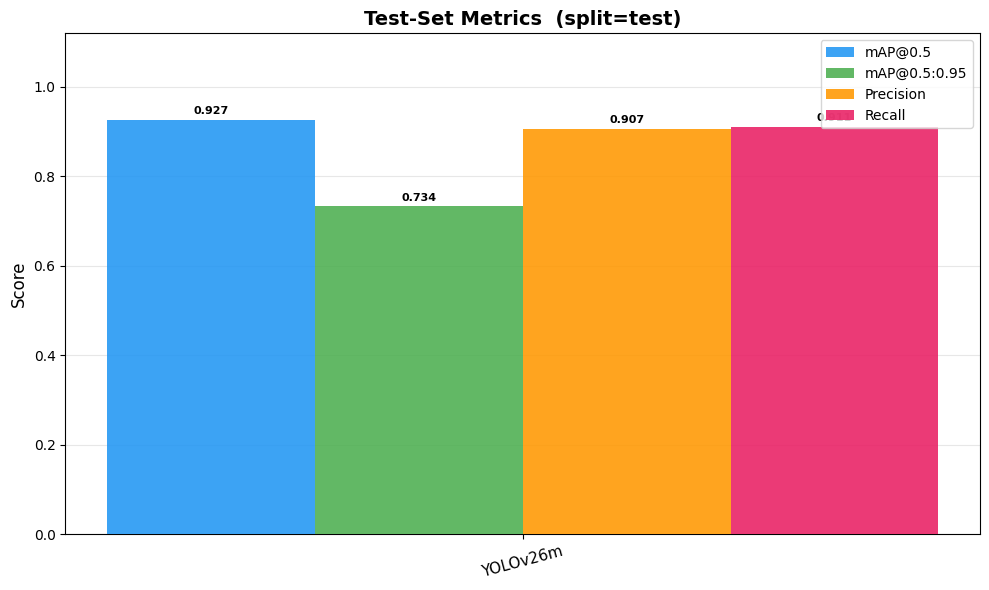

✅ Saved: /kaggle/working/yolov26_m_outputs/test_metrics_bar.png


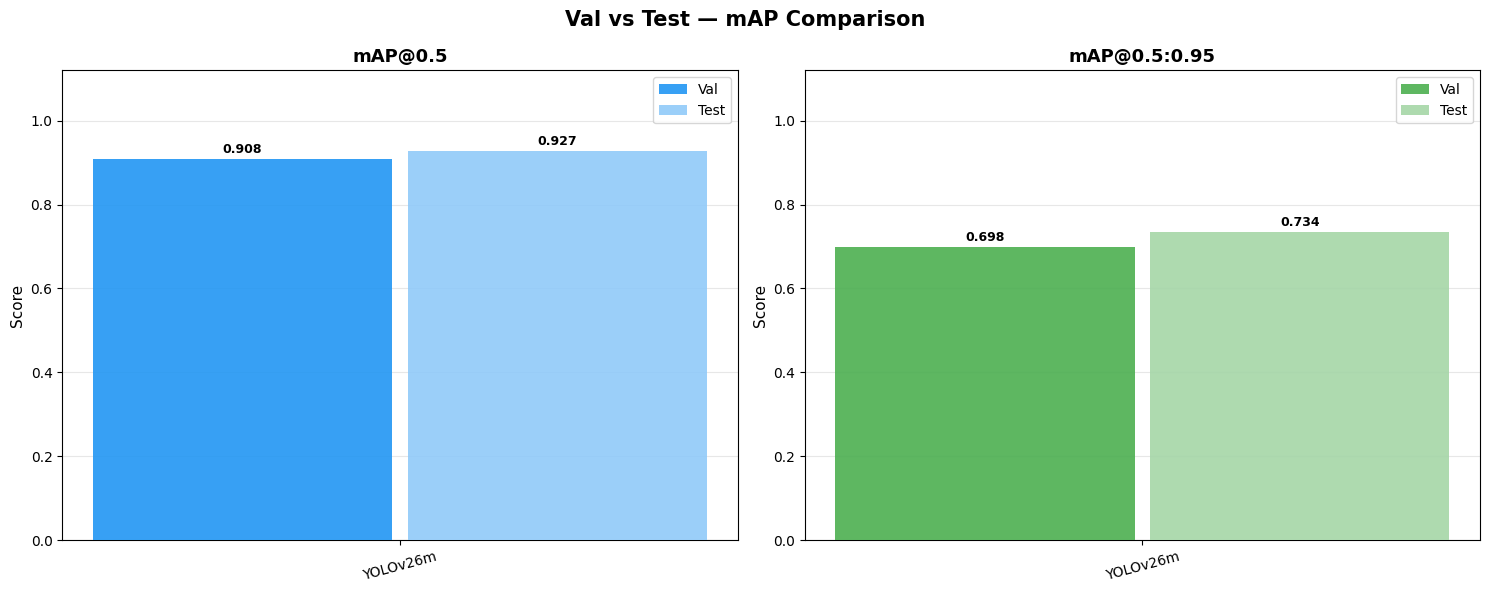

✅ Saved: /kaggle/working/yolov26_m_outputs/val_vs_test_comparison.png


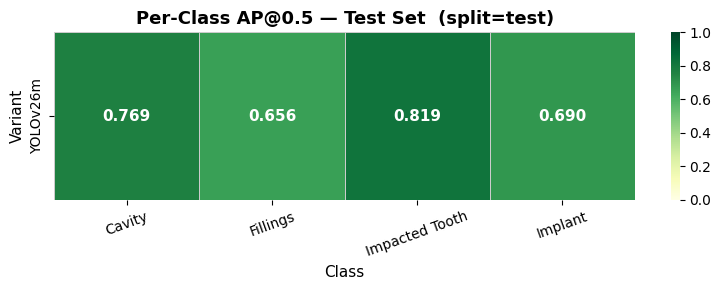

✅ Saved: /kaggle/working/yolov26_m_outputs/test_per_class_ap_heatmap.png


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 6b: Test-set evaluation — mAP@0.5, mAP@0.5:0.95, Precision, Recall
#           + per-class AP breakdown + Val vs Test comparison chart
#
# Uses the 'test' split defined in data.yaml (falls back to 'val' if absent).
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO

# ── Resolve test path from data.yaml ─────────────────────────────────────────
import yaml
with open(data_yaml_path) as f:
    _dy = yaml.safe_load(f)

_test_key = _dy.get('test')
if _test_key:
    print(f'✅ Test split found in data.yaml: {_test_key}')
    _test_data = str(data_yaml_path)   # pass the yaml; YOLO reads test key
    _split     = 'test'
else:
    print('⚠️  No test split in data.yaml — falling back to val split.')
    _test_data = str(data_yaml_path)
    _split     = 'val'

# ── Run test evaluation for every variant ────────────────────────────────────
test_rows        = []
test_perclass    = {}

for variant_name, _, run_name in CFG['variants']:
    best_weights = Path(CFG['output_dir']) / run_name / 'weights' / 'best.pt'
    if not best_weights.exists():
        print(f'⚠️  {variant_name}: best.pt not found, skipping test eval.')
        continue

    print(f'\n🔍 Test evaluation — {variant_name}  (split={_split})')
    model = YOLO(str(best_weights))

    test_results = model.val(
        data     = _test_data,
        split    = _split,          # 'test' or 'val' fallback
        imgsz    = CFG['image_size'],
        batch    = CFG['batch_size'],
        device   = CFG['device'],
        project  = CFG['output_dir'],
        name     = f'{run_name}_test',
        exist_ok = True,
        conf     = CFG['conf_threshold'],
        iou      = CFG['iou_threshold'],
        verbose  = False,
    )

    rd = test_results.results_dict if hasattr(test_results, 'results_dict') else {}

    map50    = round(rd.get('metrics/mAP50(B)',    0), 4)
    map5095  = round(rd.get('metrics/mAP50-95(B)', 0), 4)
    prec     = round(rd.get('metrics/precision(B)', 0), 4)
    rec      = round(rd.get('metrics/recall(B)',    0), 4)

    print(f'   mAP@0.5={map50:.4f}  mAP@0.5:0.95={map5095:.4f}  '
          f'Precision={prec:.4f}  Recall={rec:.4f}')

    test_rows.append({
        'Variant':      variant_name,
        'mAP@0.5':      map50,
        'mAP@0.5:0.95': map5095,
        'Precision':    prec,
        'Recall':       rec,
        'Split':        _split,
    })

    # Per-class AP50
    try:
        test_perclass[variant_name] = list(test_results.box.maps)
    except Exception:
        test_perclass[variant_name] = [0.0] * len(CFG['classes'])

test_df = pd.DataFrame(test_rows)

# Save CSV
test_csv = Path(CFG['output_dir']) / 'test_metrics.csv'
test_df.to_csv(test_csv, index=False)
print(f'\n✅ Test metrics saved → {test_csv}')

print('\n' + '═'*65)
print(f'  📋 Test Metrics (split={_split})')
print('═'*65)
print(test_df[['Variant','mAP@0.5','mAP@0.5:0.95','Precision','Recall']].to_string(index=False))

# ── Figure 1: Test metrics bar chart ─────────────────────────────────────────
COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
variants = test_df['Variant'].tolist()
x = np.arange(len(variants))
w = 0.2

fig, ax = plt.subplots(figsize=(max(10, len(variants) * 2.5), 6))

metrics_plot = ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall']
offsets      = [-1.5, -0.5, 0.5, 1.5]

bars_list = []
for metric, offset, color in zip(metrics_plot, offsets, COLORS):
    bars = ax.bar(x + offset * w, test_df[metric], w,
                  label=metric, color=color, alpha=0.88, zorder=3)
    bars_list.append(bars)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(variants, rotation=15, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title(f'Test-Set Metrics  (split={_split})', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
out1 = Path(CFG['output_dir']) / 'test_metrics_bar.png'
plt.savefig(out1, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {out1}')

# ── Figure 2: Val vs Test side-by-side comparison ────────────────────────────
if 'metrics_df' in dir() and not metrics_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    compare_metrics = ['mAP@0.5', 'mAP@0.5:0.95']
    pair_colors     = [('#2196F3', '#90CAF9'), ('#4CAF50', '#A5D6A7')]  # (val, test)

    for ax, metric, (c_val, c_test) in zip(axes, compare_metrics, pair_colors):
        val_scores  = metrics_df.set_index('Variant')[metric].reindex(variants).fillna(0)
        test_scores = test_df.set_index('Variant')[metric].reindex(variants).fillna(0)

        bv = ax.bar(x - 0.2, val_scores,  0.38, label='Val',  color=c_val,  alpha=0.9, zorder=3)
        bt = ax.bar(x + 0.2, test_scores, 0.38, label='Test', color=c_test, alpha=0.9, zorder=3)

        for bar in list(bv) + list(bt):
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(variants, rotation=15, fontsize=10)
        ax.set_ylim(0, 1.12)
        ax.set_title(metric, fontsize=13, fontweight='bold')
        ax.set_ylabel('Score', fontsize=11)
        ax.legend(fontsize=10)
        ax.grid(axis='y', alpha=0.3, zorder=0)
        ax.set_axisbelow(True)

    fig.suptitle('Val vs Test — mAP Comparison', fontsize=15, fontweight='bold')
    plt.tight_layout()
    out2 = Path(CFG['output_dir']) / 'val_vs_test_comparison.png'
    plt.savefig(out2, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {out2}')
else:
    print('ℹ️  metrics_df not available — skipping Val vs Test chart.')

# ── Figure 3: Per-class AP@0.5 on test set ───────────────────────────────────
if test_perclass:
    hm_data     = np.array([test_perclass[v] for v, _, _ in CFG['variants'] if v in test_perclass])
    hm_variants = [v for v, _, _ in CFG['variants'] if v in test_perclass]

    fig, ax = plt.subplots(figsize=(max(8, len(CFG['classes']) * 2), max(3, len(hm_variants) * 1.2 + 1)))
    sns.heatmap(
        hm_data,
        annot=True, fmt='.3f', cmap='YlGn',
        xticklabels=CFG['classes'],
        yticklabels=hm_variants,
        vmin=0, vmax=1, ax=ax,
        linewidths=0.5, linecolor='#cccccc',
        annot_kws={'size': 11, 'weight': 'bold'},
    )
    ax.set_title(f'Per-Class AP@0.5 — Test Set  (split={_split})',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Class',   fontsize=11)
    ax.set_ylabel('Variant', fontsize=11)
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    out3 = Path(CFG['output_dir']) / 'test_per_class_ap_heatmap.png'
    plt.savefig(out3, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {out3}')


Using split="test" for test curves.

🔍 YOLOv26m: scanning 16 checkpoint(s) on split="test"…
Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,352,536 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1243.1±256.8 MB/s, size: 35.5 KB)
val: Scanning /kaggle/working/balanced_dataset/test/labels.cache... 107 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 107/107 40.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.6it/s 4.4s0.7ss
                   all        107        739      0.486       0.42      0.472       0.17
Speed: 3.8ms preprocess, 30.2ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /kaggle/working/yolov26_m_outputs/dental_yolov26m_6c_val
Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,352,536 pa

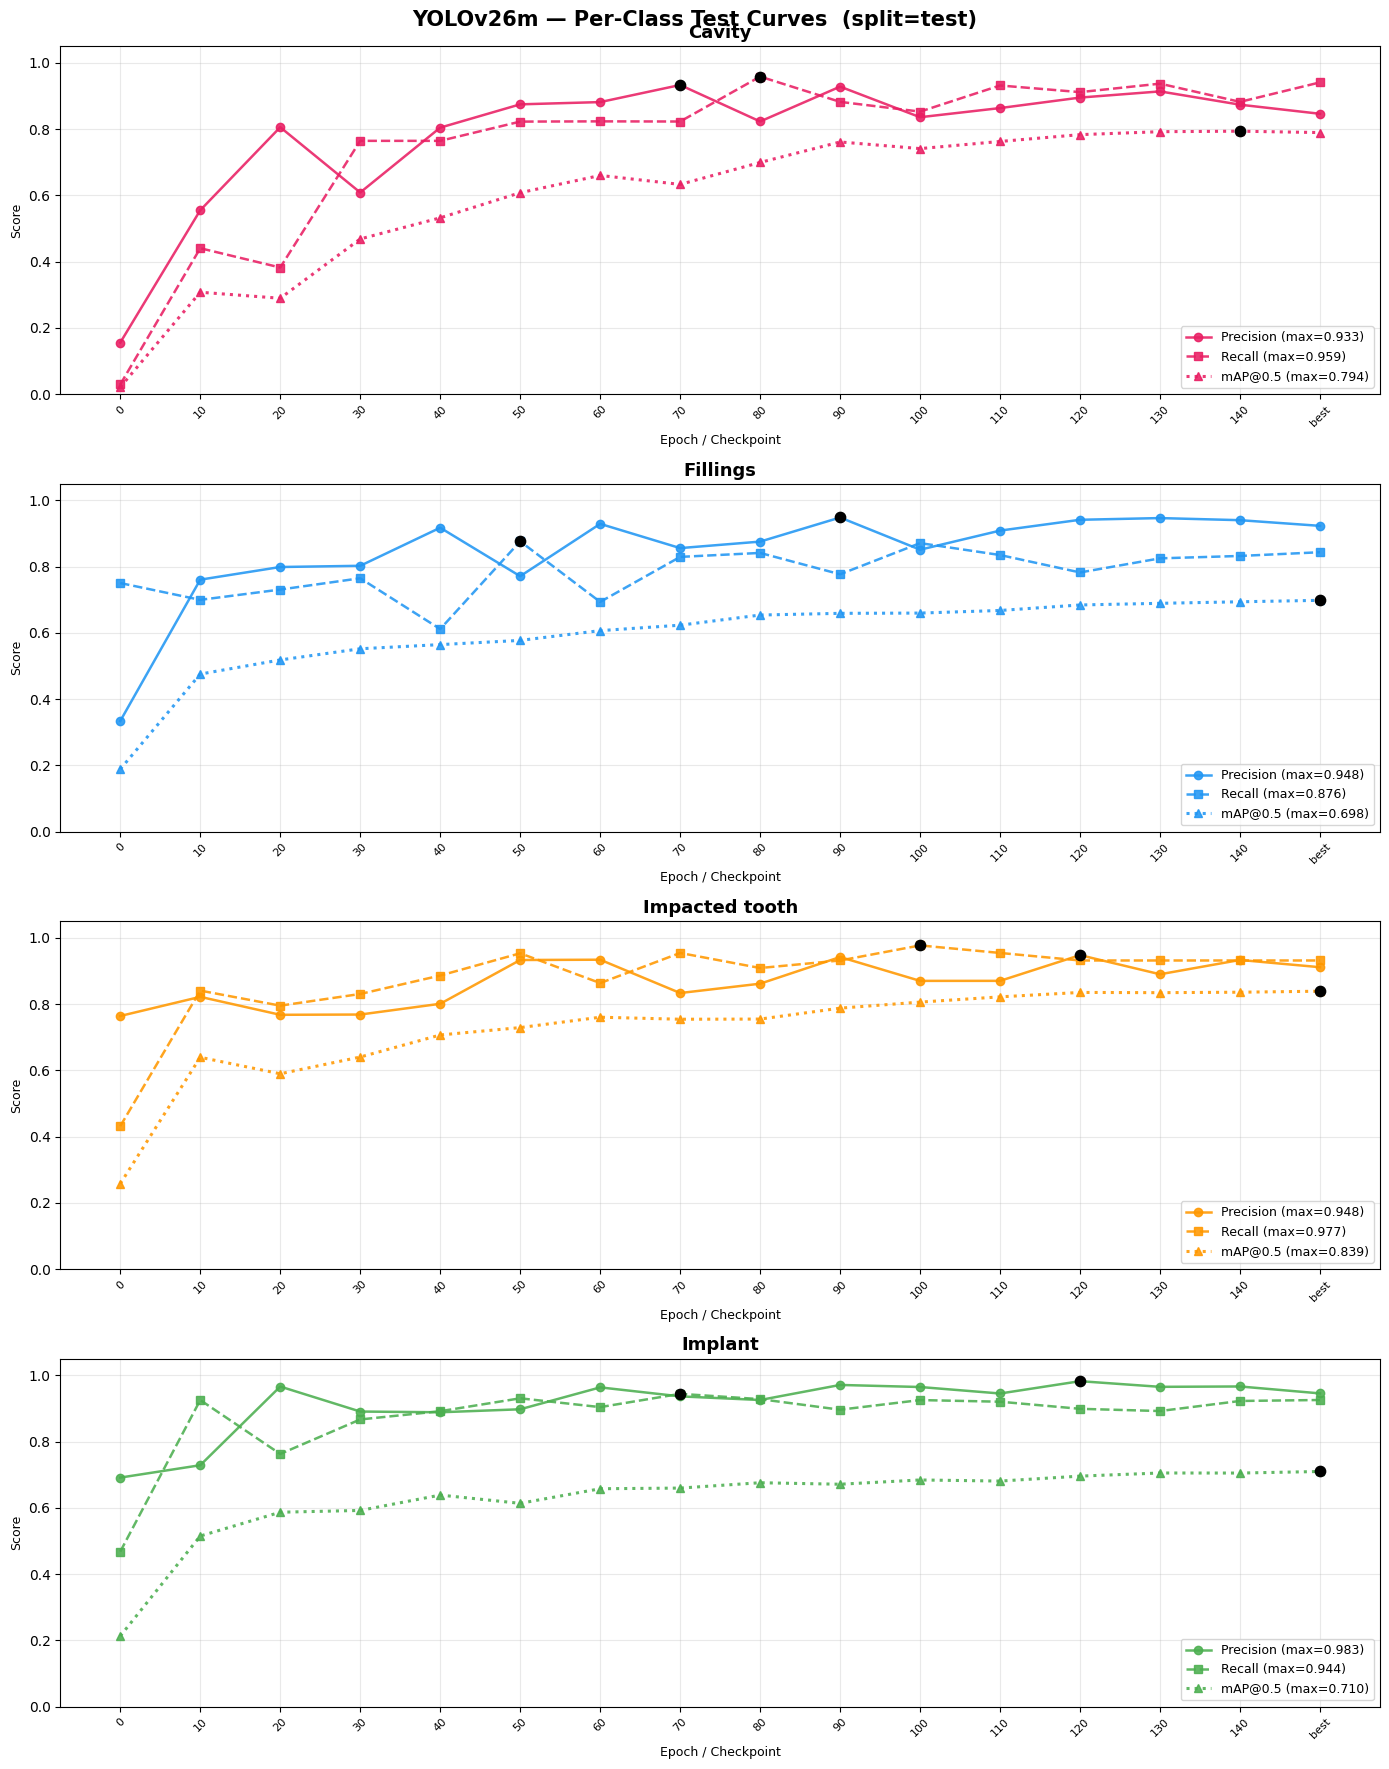

✅ Saved: /kaggle/working/yolov26_m_outputs/dental_yolov26m_test_per_class_curves.png


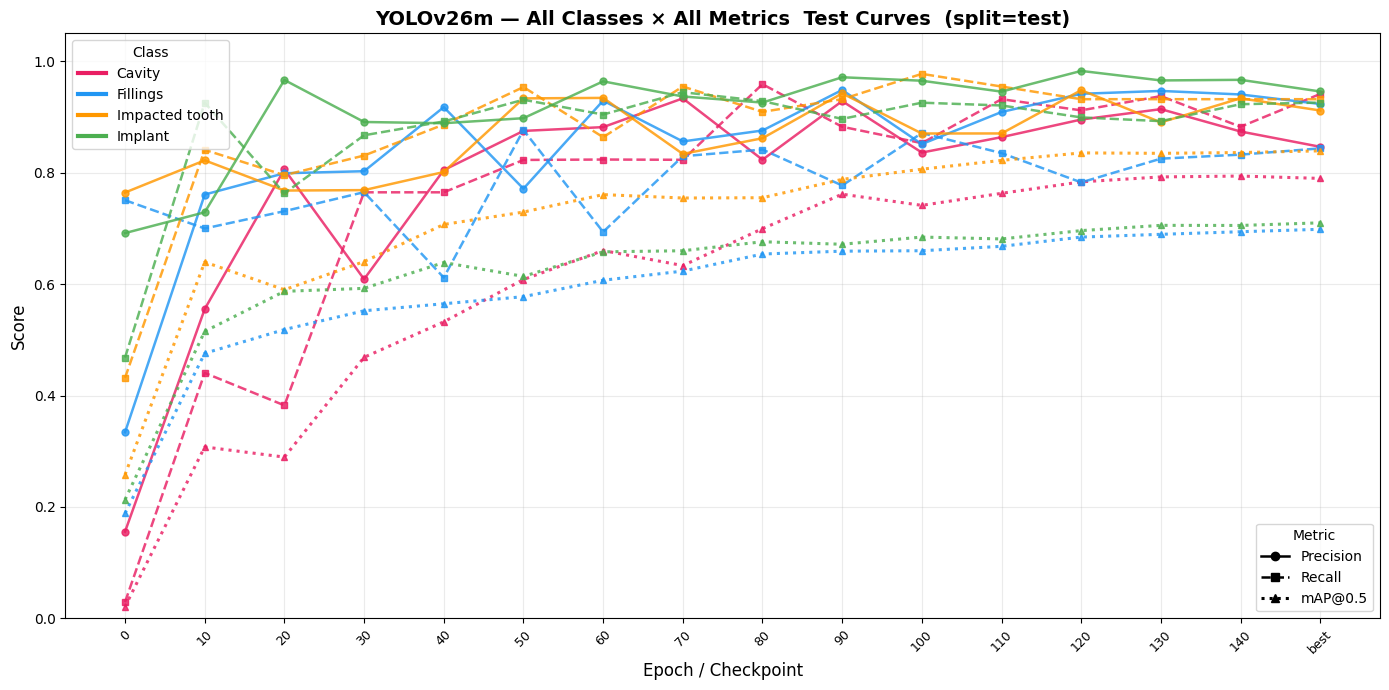

✅ Saved: /kaggle/working/yolov26_m_outputs/dental_yolov26m_test_all_classes_curves.png


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 6c: Test-set curves — per-class AND all-in-one
#
#  Scans every saved epoch checkpoint (epoch10.pt, epoch20.pt … best.pt),
#  runs model.val(split='test') on each, and plots:
#
#  Figure A — Per-class subplots (one per class):  Precision / Recall / mAP@0.5
#  Figure B — All-classes all-in-one overlay:      same three metrics, all classes
#
#  Both figures are saved to the output directory.
# ─────────────────────────────────────────────────────────────────────────────
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path
from ultralytics import YOLO
import yaml
# ── Resolve test split (reuse logic from Cell 6b) ────────────────────────────
with open(data_yaml_path) as _f:
    _dy = yaml.safe_load(_f)
_split = 'test' if _dy.get('test') else 'val'
print(f'Using split="{_split}" for test curves.')
# ── Style maps ───────────────────────────────────────────────────────────────
CLASS_COLORS = {
    'Cavity':   '#E91E63',
    'Fillings':  '#2196F3',
    'Impacted Tooth': '#FF9800',
    'Implant':  '#4CAF50',
}
METRIC_STYLES = {
    'Precision': ('-',  'o',  1.8),
    'Recall':    ('--', 's',  1.8),
    'mAP@0.5':   (':',  '^',  2.2),
}
for variant_name, _, run_name in CFG['variants']:
    weights_dir = Path(CFG['output_dir']) / run_name / 'weights'
    if not weights_dir.exists():
        print(f'⚠️  {variant_name}: weights dir not found'); continue
    # Collect epoch checkpoints + best.pt
    ckpt_files = sorted(
        weights_dir.glob('epoch*.pt'),
        key=lambda p: int(re.search(r'epoch(\d+)', p.stem).group(1))
    )
    best_pt = weights_dir / 'best.pt'
    if best_pt.exists() and best_pt not in ckpt_files:
        ckpt_files.append(best_pt)
    if not ckpt_files:
        print(f'⚠️  {variant_name}: no checkpoints found — only best.pt will be used.')
        ckpt_files = [best_pt] if best_pt.exists() else []
    if not ckpt_files:
        continue
    classes   = CFG['classes']
    nc        = len(classes)
    # Storage: per-class × per-metric
    epoch_labels = []
    data = {cls: {'Precision': [], 'Recall': [], 'mAP@0.5': []} for cls in classes}
    print(f'\n🔍 {variant_name}: scanning {len(ckpt_files)} checkpoint(s) on split="{_split}"…')
    for ckpt in ckpt_files:
        ep_match = re.search(r'epoch(\d+)', ckpt.stem)
        epoch_labels.append(int(ep_match.group(1)) if ep_match else 'best')
        m  = YOLO(str(ckpt))
        vr = m.val(
            data     = str(data_yaml_path),
            split    = _split,
            imgsz    = CFG['image_size'],
            batch    = CFG['batch_size'],
            device   = CFG['device'],
            project  = CFG['output_dir'],
            name     = f'{run_name}_6c_val',
            exist_ok = True,
            verbose  = False,
        )
        try:
            ap_idx  = list(vr.box.ap_class_index)
            ap_v    = list(vr.box.ap)
            p_v     = list(vr.box.p)
            r_v     = list(vr.box.r)
            idx_map = {idx: pos for pos, idx in enumerate(ap_idx)}
            for ci, cls in enumerate(classes):
                pos = idx_map.get(ci)
                data[cls]['Precision'].append(p_v[pos]  if pos is not None else 0.0)
                data[cls]['Recall'].append(   r_v[pos]  if pos is not None else 0.0)
                data[cls]['mAP@0.5'].append(  ap_v[pos] if pos is not None else 0.0)
        except Exception as e:
            print(f'   ⚠️  Could not extract metrics from {ckpt.name}: {e}')
            for cls in classes:
                data[cls]['Precision'].append(0.0)
                data[cls]['Recall'].append(0.0)
                data[cls]['mAP@0.5'].append(0.0)
    x = list(range(len(epoch_labels)))
    x_ticks = [str(e) for e in epoch_labels]
    # ─────────────────────────────────────────────────────────────────────────
    # Figure A: Per-class subplots — one row per class (full-width)
    # ─────────────────────────────────────────────────────────────────────────
    fig_a, axes_a = plt.subplots(nc, 1,
                                  figsize=(14, 4.5 * nc),
                                  sharey=True)
    if nc == 1:
        axes_a = [axes_a]
    for ax, cls in zip(axes_a, classes):
        color = CLASS_COLORS.get(cls, '#333333')
        for metric, (ls, marker, lw) in METRIC_STYLES.items():
            vals = data[cls][metric]
            ax.plot(x, vals,
                    ls=ls, marker=marker, color=color,
                    lw=lw, markersize=6, alpha=0.88,
                    label=f'{metric} (max={max(vals):.3f})' if vals else metric)
            if vals:
                best_i = int(np.argmax(vals))
                ax.scatter(x[best_i], vals[best_i],
                           color='black', zorder=6, s=55)
        ax.set_title(cls.capitalize(), fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(x_ticks, rotation=45, fontsize=8)
        ax.set_xlabel('Epoch / Checkpoint', fontsize=9)
        ax.set_ylabel('Score', fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=9, loc='lower right')
        ax.grid(alpha=0.28)
    fig_a.suptitle(
        f'{variant_name} — Per-Class Test Curves  (split={_split})',
        fontsize=15, fontweight='bold'
    )
    plt.tight_layout()
    out_a = Path(CFG['output_dir']) / f'{run_name}_test_per_class_curves.png'
    plt.savefig(out_a, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {out_a}')
    # ─────────────────────────────────────────────────────────────────────────
    # Figure B: All-classes all-in-one overlay
    # ─────────────────────────────────────────────────────────────────────────
    fig_b, ax_b = plt.subplots(figsize=(14, 7))
    for cls in classes:
        color = CLASS_COLORS.get(cls, '#333333')
        for metric, (ls, marker, lw) in METRIC_STYLES.items():
            vals = data[cls][metric]
            ax_b.plot(x, vals,
                      ls=ls, marker=marker, color=color,
                      lw=lw, markersize=5, alpha=0.82)
    ax_b.set_xticks(x)
    ax_b.set_xticklabels(x_ticks, rotation=45, fontsize=9)
    ax_b.set_xlabel('Epoch / Checkpoint', fontsize=12)
    ax_b.set_ylabel('Score', fontsize=12)
    ax_b.set_ylim(0, 1.05)
    ax_b.set_title(
        f'{variant_name} — All Classes × All Metrics  Test Curves  (split={_split})',
        fontsize=14, fontweight='bold'
    )
    ax_b.grid(alpha=0.25)
    # Two-level legend
    class_handles = [
        mlines.Line2D([], [], color=CLASS_COLORS.get(c, '#333'), lw=3, label=c.capitalize())
        for c in classes
    ]
    metric_handles_b = [
        mlines.Line2D([], [], color='black', ls=ls, marker=mk,
                      lw=lw, markersize=6, label=m)
        for m, (ls, mk, lw) in METRIC_STYLES.items()
    ]
    leg1 = ax_b.legend(handles=class_handles,    title='Class',
                        loc='upper left',  fontsize=10, title_fontsize=10)
    leg2 = ax_b.legend(handles=metric_handles_b, title='Metric',
                        loc='lower right', fontsize=10, title_fontsize=10)
    ax_b.add_artist(leg1)
    plt.tight_layout()
    out_b = Path(CFG['output_dir']) / f'{run_name}_test_all_classes_curves.png'
    plt.savefig(out_b, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {out_b}')


## 7. 📈 Visualizations

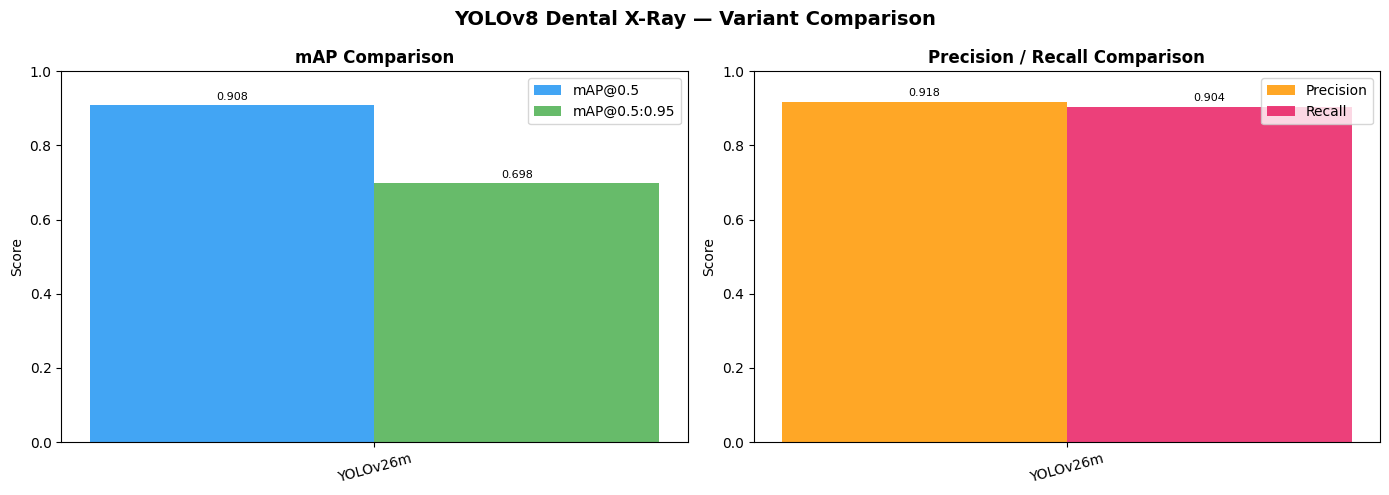

✅ Comparison chart saved.


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7a: Side-by-side mAP bar chart comparison
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

if not metrics_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
    variants = metrics_df['Variant'].tolist()
    x = np.arange(len(variants))

    # mAP@0.5 vs mAP@0.5:0.95
    ax = axes[0]
    w = 0.35
    b1 = ax.bar(x - w/2, metrics_df['mAP@0.5'],      w, label='mAP@0.5',      color='#2196F3', alpha=0.85)
    b2 = ax.bar(x + w/2, metrics_df['mAP@0.5:0.95'], w, label='mAP@0.5:0.95', color='#4CAF50', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(variants, rotation=15)
    ax.set_ylabel('Score'); ax.set_title('mAP Comparison', fontweight='bold')
    ax.legend(); ax.set_ylim(0, 1)
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

    # Precision vs Recall
    ax = axes[1]
    b3 = ax.bar(x - w/2, metrics_df['Precision'], w, label='Precision', color='#FF9800', alpha=0.85)
    b4 = ax.bar(x + w/2, metrics_df['Recall'],    w, label='Recall',    color='#E91E63', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(variants, rotation=15)
    ax.set_ylabel('Score'); ax.set_title('Precision / Recall Comparison', fontweight='bold')
    ax.legend(); ax.set_ylim(0, 1)
    for bar in list(b3) + list(b4):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

    plt.suptitle('YOLOv8 Dental X-Ray — Variant Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{CFG["output_dir"]}/variant_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Comparison chart saved.')

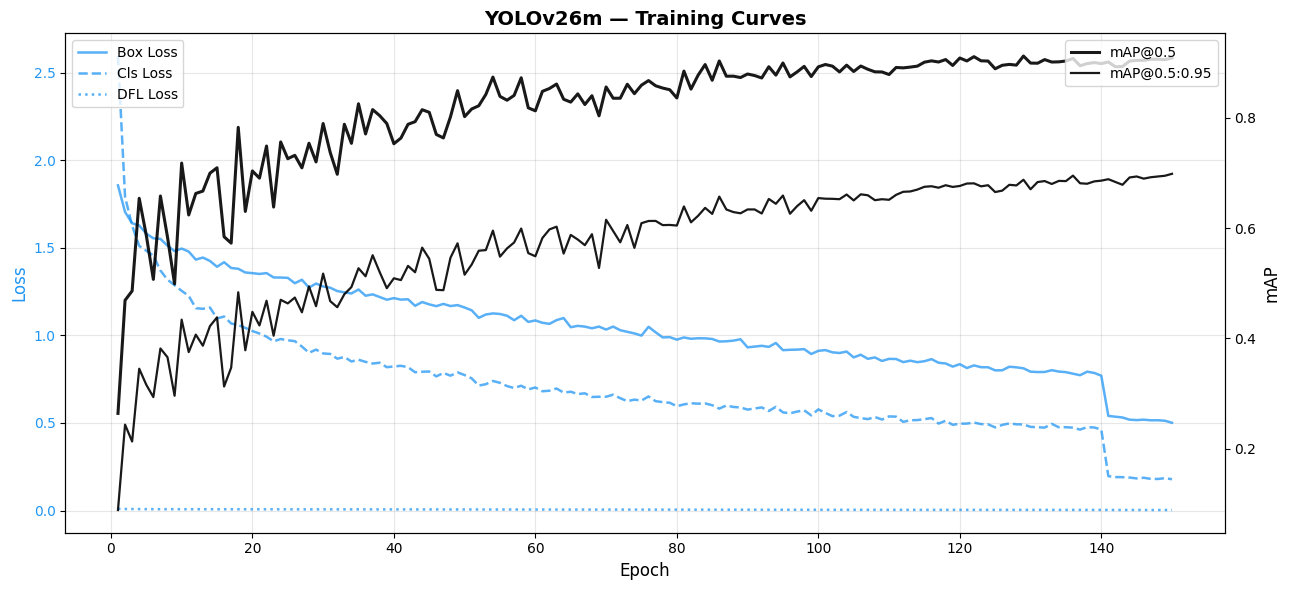

✅ Saved: /kaggle/working/yolov26_m_outputs/dental_yolov26m_training_curves.png


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7b: Training loss curves from results.csv — this variant only
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

variant_name, _, run_name = CFG['variants'][0]
csv_path = Path(CFG['output_dir']) / run_name / 'results.csv'

if not csv_path.exists():
    print(f'⚠️  results.csv not found at {csv_path}')
else:
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    epochs = df.get('epoch', range(len(df)))
    color  = '#2196F3'

    fig, ax = plt.subplots(figsize=(13, 6))
    ax2 = ax.twinx()

    # Loss curves (left axis)
    for loss_col, ls, lbl in [
        ('train/box_loss', '-',  'Box Loss'),
        ('train/cls_loss', '--', 'Cls Loss'),
        ('train/dfl_loss', ':',  'DFL Loss'),
    ]:
        if loss_col in df.columns:
            ax.plot(epochs, df[loss_col], ls=ls, color=color, alpha=0.75, lw=1.8, label=lbl)

    # mAP curves (right axis)
    for map_col, lw, lbl in [
        ('metrics/mAP50(B)',    2.2, 'mAP@0.5'),
        ('metrics/mAP50-95(B)', 1.6, 'mAP@0.5:0.95'),
    ]:
        if map_col in df.columns:
            ax2.plot(epochs, df[map_col], color='black', lw=lw, alpha=0.9, label=lbl)

    ax.set_title(f'{variant_name} — Training Curves', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss',  fontsize=12, color=color)
    ax2.set_ylabel('mAP',  fontsize=12, color='black')
    ax.tick_params(axis='y', labelcolor=color)
    ax.legend(loc='upper left',  fontsize=10)
    ax2.legend(loc='upper right', fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    out_png = Path(CFG['output_dir']) / f'{run_name}_training_curves.png'
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {out_png}')

🏆 Best variant: YOLOv26m  (mAP@0.5 = 0.9083)


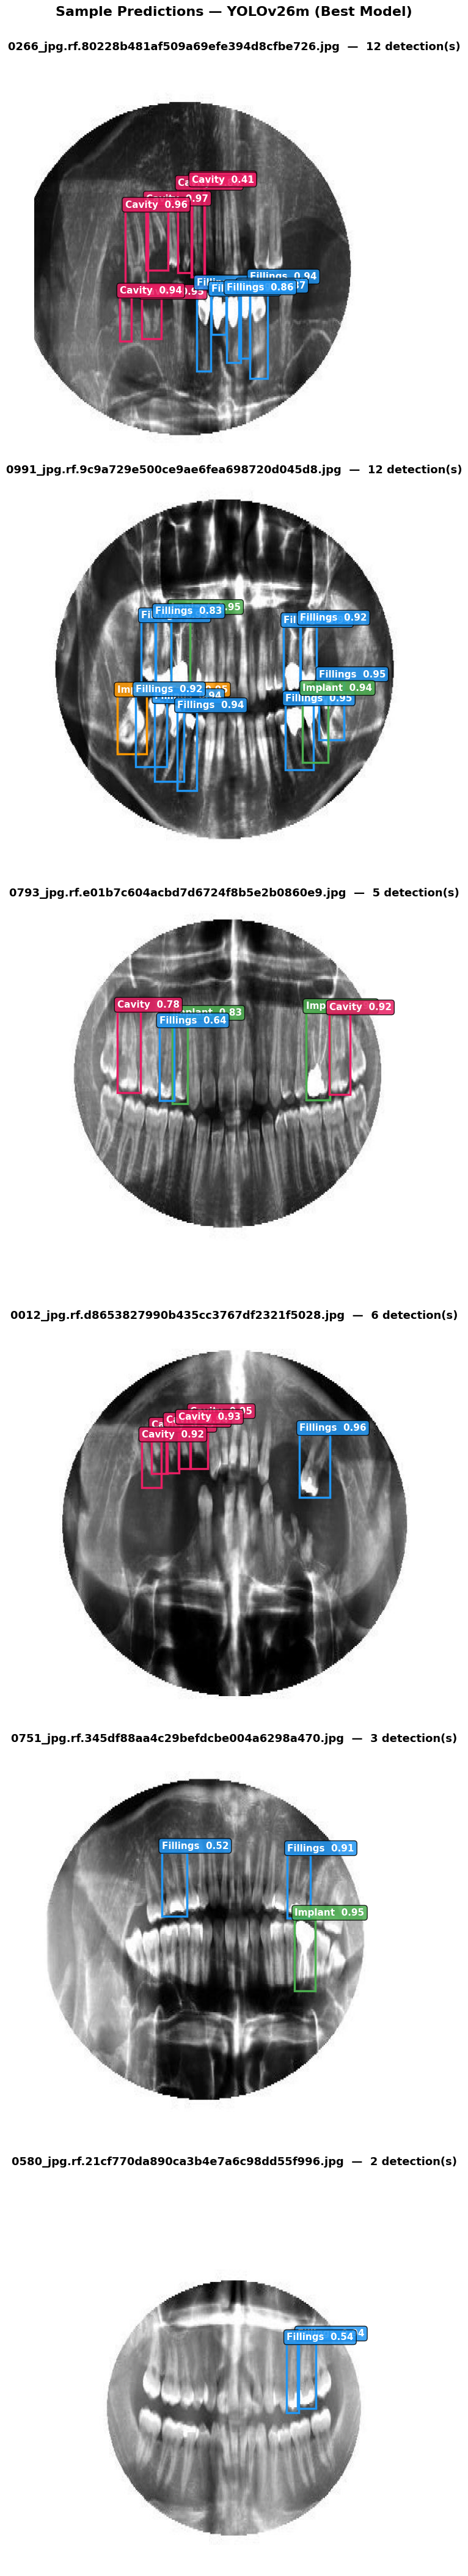

✅ Saved: /kaggle/working/yolov26_m_outputs/sample_predictions.png


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7c: Sample predictions — single column, large images
# ─────────────────────────────────────────────────────────────────────────────
import random
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
N_SAMPLES = 6   # number of val images to display
if not metrics_df.empty:
    best_variant_row = metrics_df.loc[metrics_df['mAP@0.5'].idxmax()]
    best_variant     = best_variant_row['Variant']
    best_run         = next(run for name, _, run in CFG['variants'] if name == best_variant)
    best_weights     = Path(CFG['output_dir']) / best_run / 'weights' / 'best.pt'
    print(f'🏆 Best variant: {best_variant}  (mAP@0.5 = {best_variant_row["mAP@0.5"]:.4f})')
    model = YOLO(str(best_weights))
    val_images  = list(val_dir.rglob('*.jpg')) + list(val_dir.rglob('*.png'))
    sample_imgs = random.sample(val_images, min(N_SAMPLES, len(val_images)))
    CLASS_COLORS = {
        'Cavity':   '#E91E63',
        'Fillings':  '#2196F3',
        'Impacted Tooth': '#FF9800',
        'Implant':  '#4CAF50',
    }
    fig, axes = plt.subplots(N_SAMPLES, 1, figsize=(14, 7 * N_SAMPLES))
    if N_SAMPLES == 1:
        axes = [axes]
    for ax, img_path in zip(axes, sample_imgs):
        results = model.predict(
            str(img_path),
            conf    = CFG['conf_threshold'],
            iou     = CFG['iou_threshold'],
            verbose = False,
        )
        img = np.array(PILImage.open(img_path).convert('RGB'))
        ax.imshow(img)
        n_boxes = 0
        for result in results:
            if result.boxes is not None:
                for box in result.boxes:
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    cls_id   = int(box.cls[0])
                    conf_val = float(box.conf[0])
                    cls_name = CFG['classes'][cls_id] if cls_id < len(CFG['classes']) else str(cls_id)
                    color    = CLASS_COLORS.get(cls_name, '#FFFFFF')
                    n_boxes += 1
                    rect = patches.Rectangle(
                        (x1, y1), x2 - x1, y2 - y1,
                        linewidth=2.5, edgecolor=color, facecolor='none'
                    )
                    ax.add_patch(rect)
                    ax.text(
                        x1, max(y1 - 6, 0),
                        f'{cls_name}  {conf_val:.2f}',
                        color='white', fontsize=11, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.85)
                    )
        ax.set_title(f'{img_path.name}  —  {n_boxes} detection(s)', fontsize=13, fontweight='bold')
        ax.axis('off')
    fig.suptitle(
        f'Sample Predictions — {best_variant} (Best Model)',
        fontsize=16, fontweight='bold', y=1.002
    )
    plt.tight_layout()
    out_png = Path(CFG['output_dir']) / 'sample_predictions.png'
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {out_png}')
else:
    print('⚠️  No metrics available — run Cell 6 first.')


Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,352,536 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 952.3±225.2 MB/s, size: 34.3 KB)
val: Scanning /kaggle/working/balanced_dataset/valid/labels.cache... 215 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 215/215 100.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 1.8it/s 7.8s0.5s
                   all        215       1657      0.918      0.904      0.943      0.724
Speed: 2.1ms preprocess, 28.5ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /kaggle/working/yolov26_m_outputs/dental_yolov26m_perclass


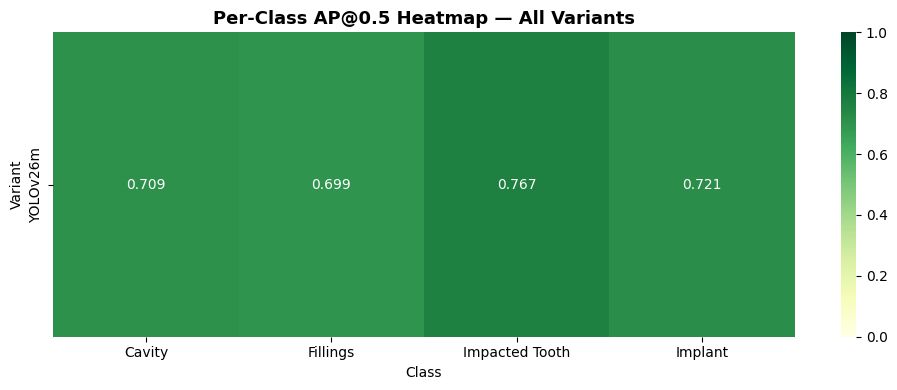

✅ Per-class AP heatmap saved.


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7d: Per-class AP heatmap across all variants
# ─────────────────────────────────────────────────────────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Re-run validation with per-class metrics
per_class_data = {}

for variant_name, _, run_name in CFG['variants']:
    best_weights = Path(CFG['output_dir']) / run_name / 'weights' / 'best.pt'
    if not best_weights.exists():
        continue

    model = YOLO(str(best_weights))
    val_r = model.val(
        data=str(data_yaml_path), imgsz=CFG['image_size'],
        batch=CFG['batch_size'], device=CFG['device'],
        project=CFG['output_dir'], name=f'{run_name}_perclass',
        exist_ok=True, verbose=False,
    )

    # Extract per-class AP50
    try:
        maps = val_r.box.maps  # array of AP50 per class
        per_class_data[variant_name] = maps
    except AttributeError:
        per_class_data[variant_name] = [0] * len(CFG['classes'])

if per_class_data:
    heatmap_data = np.array([per_class_data[v] for v, _, _ in CFG['variants'] if v in per_class_data])
    variant_labels = [v for v, _, _ in CFG['variants'] if v in per_class_data]

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(
        heatmap_data,
        annot=True, fmt='.3f', cmap='YlGn',
        xticklabels=CFG['classes'],
        yticklabels=variant_labels,
        vmin=0, vmax=1, ax=ax
    )
    ax.set_title('Per-Class AP@0.5 Heatmap — All Variants', fontsize=13, fontweight='bold')
    ax.set_xlabel('Class'); ax.set_ylabel('Variant')
    plt.tight_layout()
    plt.savefig(f'{CFG["output_dir"]}/per_class_ap_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Per-class AP heatmap saved.')

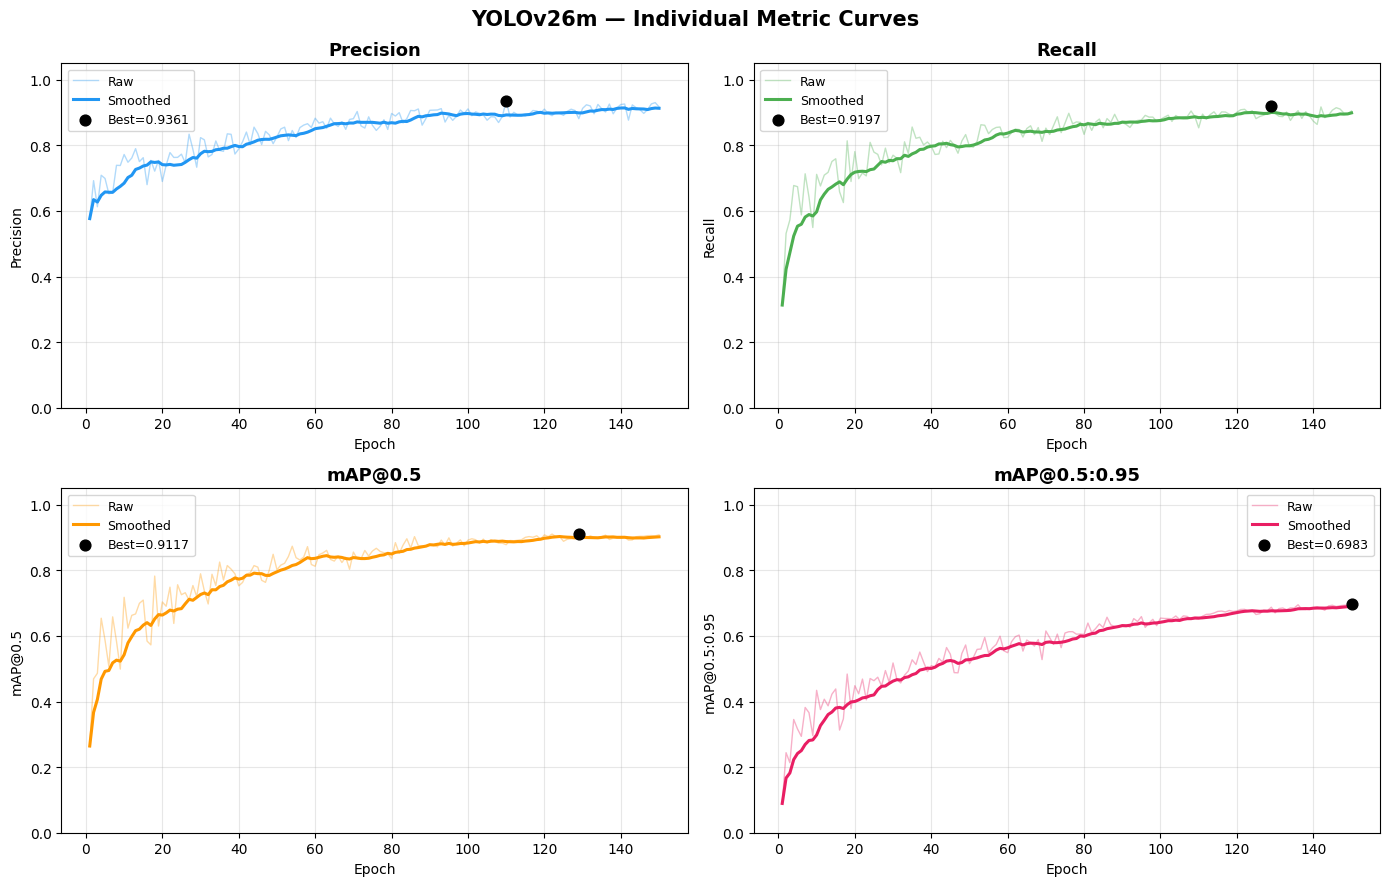

✅ Saved: /kaggle/working/yolov26_m_outputs/dental_yolov26m_metric_curves.png


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7e: Individual Precision / Recall / mAP@0.5 / mAP@0.5:0.95 curves
#           One subplot per metric, plotted over epochs from results.csv
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

METRIC_COLS = {
    'Precision':    'metrics/precision(B)',
    'Recall':       'metrics/recall(B)',
    'mAP@0.5':      'metrics/mAP50(B)',
    'mAP@0.5:0.95': 'metrics/mAP50-95(B)',
}

for variant_name, _, run_name in CFG['variants']:
    csv_path = Path(CFG['output_dir']) / run_name / 'results.csv'
    if not csv_path.exists():
        print(f'⚠️  {variant_name}: results.csv not found at {csv_path}')
        continue

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    epochs = df.get('epoch', range(len(df)))

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.flatten()
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

    for ax, (metric_label, col), color in zip(axes, METRIC_COLS.items(), colors):
        if col not in df.columns:
            ax.text(0.5, 0.5, f'{col}\nnot in results.csv',
                    ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_title(metric_label)
            continue

        series = df[col]

        # Raw curve
        ax.plot(epochs, series, color=color, alpha=0.35, lw=1, label='Raw')

        # Smoothed (rolling mean)
        smoothed = series.rolling(window=max(1, len(series)//15), min_periods=1).mean()
        ax.plot(epochs, smoothed, color=color, lw=2.2, label='Smoothed')

        # Best epoch marker
        best_idx = series.idxmax()
        ax.scatter(epochs.iloc[best_idx] if hasattr(epochs, 'iloc') else best_idx,
                   series.iloc[best_idx],
                   color='black', zorder=5, s=60, label=f'Best={series.iloc[best_idx]:.4f}')

        ax.set_title(metric_label, fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric_label)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    fig.suptitle(f'{variant_name} — Individual Metric Curves', fontsize=15, fontweight='bold')
    plt.tight_layout()
    out_png = Path(CFG['output_dir']) / f'{run_name}_metric_curves.png'
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {out_png}')

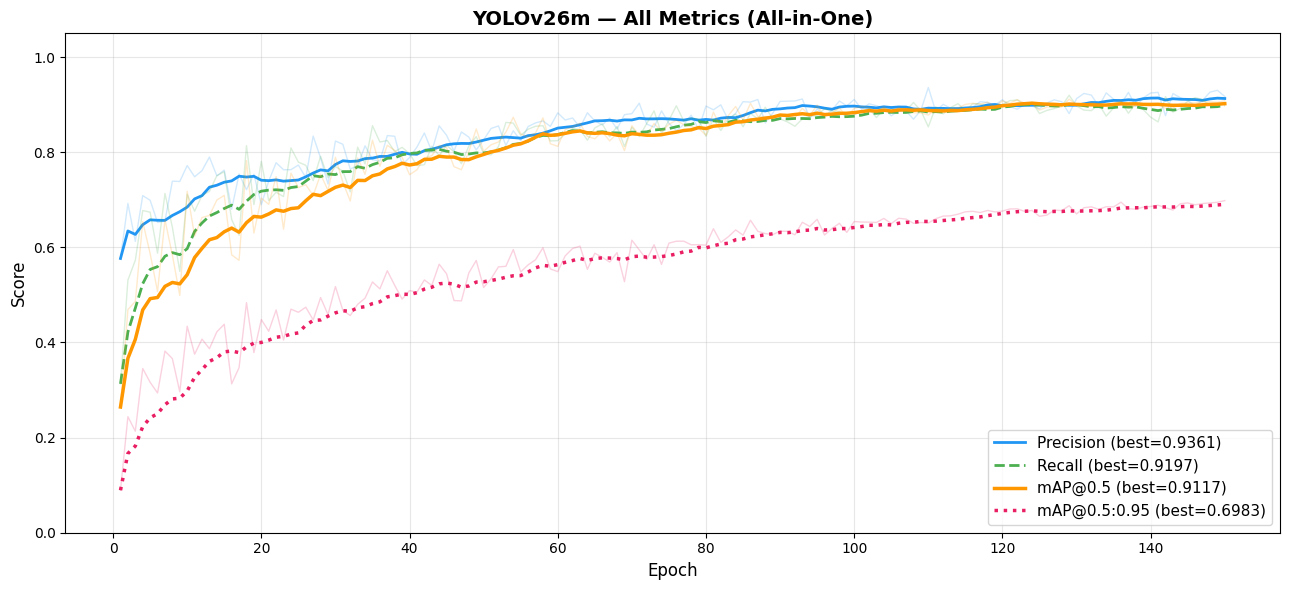

✅ Saved: /kaggle/working/yolov26_m_outputs/dental_yolov26m_all_metrics_curve.png


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7f: All-in-one curve — Precision, Recall, mAP@0.5, mAP@0.5:0.95
#           All four metrics on a single axes for easy comparison
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

METRICS = {
    'Precision':    ('metrics/precision(B)',  '#2196F3', '-',  2.0),
    'Recall':       ('metrics/recall(B)',     '#4CAF50', '--', 2.0),
    'mAP@0.5':      ('metrics/mAP50(B)',      '#FF9800', '-',  2.5),
    'mAP@0.5:0.95': ('metrics/mAP50-95(B)',   '#E91E63', ':',  2.5),
}

for variant_name, _, run_name in CFG['variants']:
    csv_path = Path(CFG['output_dir']) / run_name / 'results.csv'
    if not csv_path.exists():
        print(f'⚠️  {variant_name}: results.csv not found'); continue

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    epochs = df.get('epoch', range(len(df)))

    fig, ax = plt.subplots(figsize=(13, 6))

    for label, (col, color, ls, lw) in METRICS.items():
        if col not in df.columns:
            continue
        raw      = df[col]
        smoothed = raw.rolling(window=max(1, len(raw)//15), min_periods=1).mean()
        ax.plot(epochs, raw,      color=color, alpha=0.2, lw=1)
        ax.plot(epochs, smoothed, color=color, ls=ls, lw=lw, label=f'{label} (best={raw.max():.4f})')

    ax.set_title(f'{variant_name} — All Metrics (All-in-One)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(alpha=0.3)
    fig.tight_layout()

    out_png = Path(CFG['output_dir']) / f'{run_name}_all_metrics_curve.png'
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {out_png}')


🔍 Scanning 16 checkpoint(s) for YOLOv26m...
Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,352,536 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1209.7±260.2 MB/s, size: 32.9 KB)
val: Scanning /kaggle/working/balanced_dataset/valid/labels.cache... 215 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 215/215 112.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 1.8it/s 7.7s0.5s
                   all        215       1657      0.595      0.453      0.477      0.165
Speed: 2.3ms preprocess, 28.3ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /kaggle/working/yolov26_m_outputs/dental_yolov26m_ckpt_val
Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,352,536 parameters, 0 gradients, 67.9 GFLOPs
val: Fa

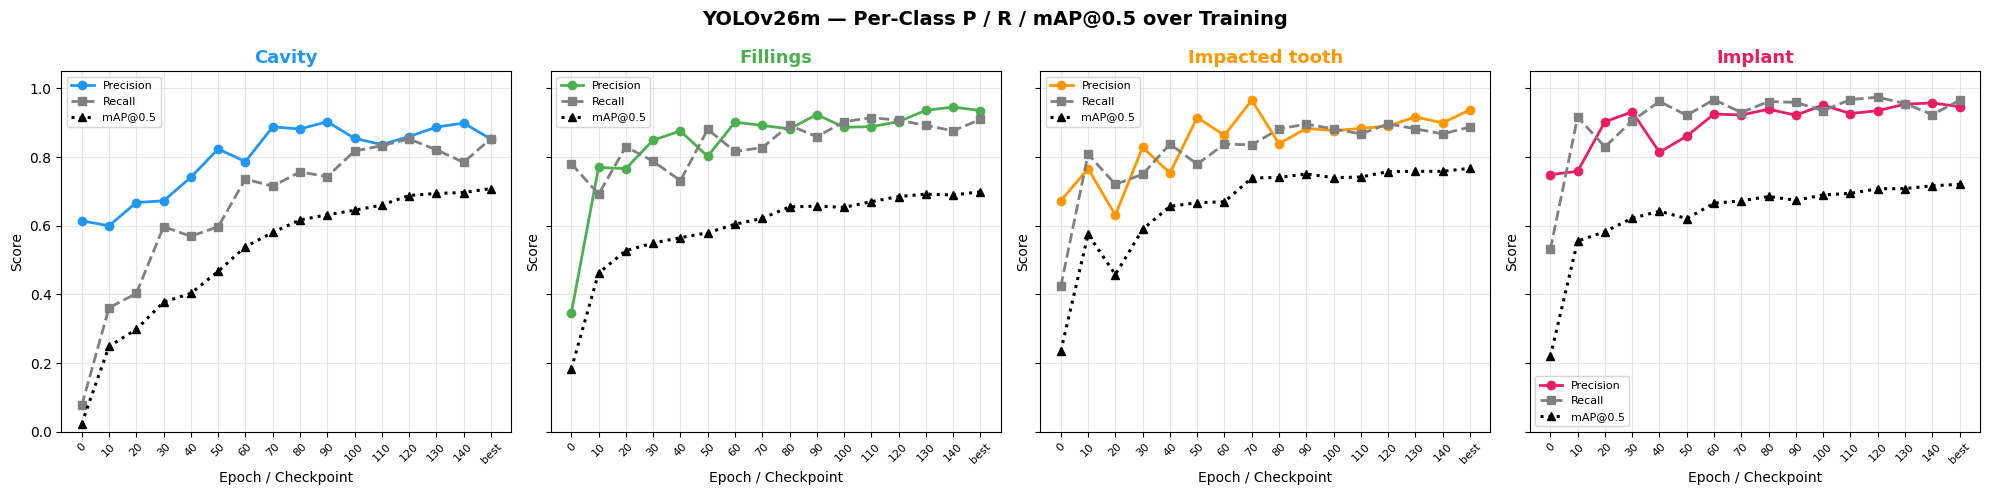

✅ Saved: /kaggle/working/yolov26_m_outputs/dental_yolov26m_per_class_curves.png


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7g: Per-class Precision / Recall / mAP@0.5 curves over training
#
# Strategy: scan saved epoch checkpoints (epoch10.pt, epoch20.pt …) produced
#           by save_period=10 during training, run .val() on each, and collect
#           per-class AP50, precision, recall.  One subplot per class.
# ─────────────────────────────────────────────────────────────────────────────
import glob, re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

for variant_name, _, run_name in CFG['variants']:
    weights_dir = Path(CFG['output_dir']) / run_name / 'weights'
    if not weights_dir.exists():
        print(f'⚠️  {variant_name}: weights dir not found'); continue

    # Collect epoch checkpoints  (epoch5.pt, epoch10.pt, …)
    ckpt_files = sorted(
        weights_dir.glob('epoch*.pt'),
        key=lambda p: int(re.search(r'epoch(\d+)', p.stem).group(1))
    )
    # Always include best.pt as the final point
    best_pt = weights_dir / 'best.pt'
    if best_pt.exists() and best_pt not in ckpt_files:
        ckpt_files.append(best_pt)

    if not ckpt_files:
        print(f'⚠️  {variant_name}: no epoch*.pt checkpoints found.')
        print('    (Tip: set save_period=10 in training to generate them.)')
        print('    Falling back to best.pt only — showing final per-class bar chart.')
        ckpt_files = [best_pt] if best_pt.exists() else []

    if not ckpt_files:
        continue

    classes   = CFG['classes']
    n_classes = len(classes)

    # epoch labels for x-axis
    epoch_labels = []
    per_class_ap  = {c: [] for c in classes}
    per_class_p   = {c: [] for c in classes}
    per_class_r   = {c: [] for c in classes}

    print(f'\n🔍 Scanning {len(ckpt_files)} checkpoint(s) for {variant_name}...')

    for ckpt in ckpt_files:
        ep_match = re.search(r'epoch(\d+)', ckpt.stem)
        ep_label = int(ep_match.group(1)) if ep_match else 'best'
        epoch_labels.append(ep_label)

        m = YOLO(str(ckpt))
        vr = m.val(
            data=str(data_yaml_path),
            imgsz=CFG['image_size'],
            batch=CFG['batch_size'],
            device=CFG['device'],
            project=CFG['output_dir'],
            name=f'{run_name}_ckpt_val',
            exist_ok=True,
            verbose=False,
        )

        try:
            # ap_class_index: which class indices are present
            # ap:  AP50 per class  |  p: precision  |  r: recall
            ap_idx = vr.box.ap_class_index.tolist() if hasattr(vr.box.ap_class_index, 'tolist') else list(vr.box.ap_class_index)
            ap_vals = vr.box.ap.tolist()   if hasattr(vr.box.ap,  'tolist') else list(vr.box.ap)
            p_vals  = vr.box.p.tolist()    if hasattr(vr.box.p,   'tolist') else list(vr.box.p)
            r_vals  = vr.box.r.tolist()    if hasattr(vr.box.r,   'tolist') else list(vr.box.r)

            idx_map = {idx: pos for pos, idx in enumerate(ap_idx)}
            for ci, cls in enumerate(classes):
                pos = idx_map.get(ci)
                per_class_ap[cls].append(ap_vals[pos] if pos is not None else 0.0)
                per_class_p[cls].append(p_vals[pos]   if pos is not None else 0.0)
                per_class_r[cls].append(r_vals[pos]   if pos is not None else 0.0)
        except Exception as e:
            print(f'   ⚠️  Could not extract per-class metrics from {ckpt.name}: {e}')
            for cls in classes:
                per_class_ap[cls].append(0.0)
                per_class_p[cls].append(0.0)
                per_class_r[cls].append(0.0)

    # ── Plot: one subplot per class, 3 lines (P / R / AP50) ────────────────
    fig, axes = plt.subplots(1, n_classes, figsize=(5*n_classes, 5), sharey=True)
    if n_classes == 1:
        axes = [axes]

    CLASS_COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
    x = list(range(len(epoch_labels)))

    for ax, cls, color in zip(axes, classes, CLASS_COLORS):
        ax.plot(x, per_class_p[cls],  'o-', color=color,     lw=2,   label='Precision')
        ax.plot(x, per_class_r[cls],  's--', color='gray',   lw=2,   label='Recall')
        ax.plot(x, per_class_ap[cls], '^:', color='black',   lw=2.2, label='mAP@0.5')
        ax.set_xticks(x)
        ax.set_xticklabels([str(e) for e in epoch_labels], rotation=45, fontsize=8)
        ax.set_title(cls.capitalize(), fontsize=13, fontweight='bold', color=color)
        ax.set_xlabel('Epoch / Checkpoint')
        ax.set_ylabel('Score')
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    fig.suptitle(f'{variant_name} — Per-Class P / R / mAP@0.5 over Training',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    out_png = Path(CFG['output_dir']) / f'{run_name}_per_class_curves.png'
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {out_png}')


🔍 YOLOv26m: collecting per-class data from 16 checkpoint(s)…
Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,352,536 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1157.4±204.7 MB/s, size: 33.8 KB)
val: Scanning /kaggle/working/balanced_dataset/valid/labels.cache... 215 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 215/215 82.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 1.8it/s 7.7s0.5s
                   all        215       1657      0.595      0.453      0.477      0.165
Speed: 2.3ms preprocess, 28.3ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /kaggle/working/yolov26_m_outputs/dental_yolov26m_aio_val
Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,352,536 parameters, 0 gradients, 67.9

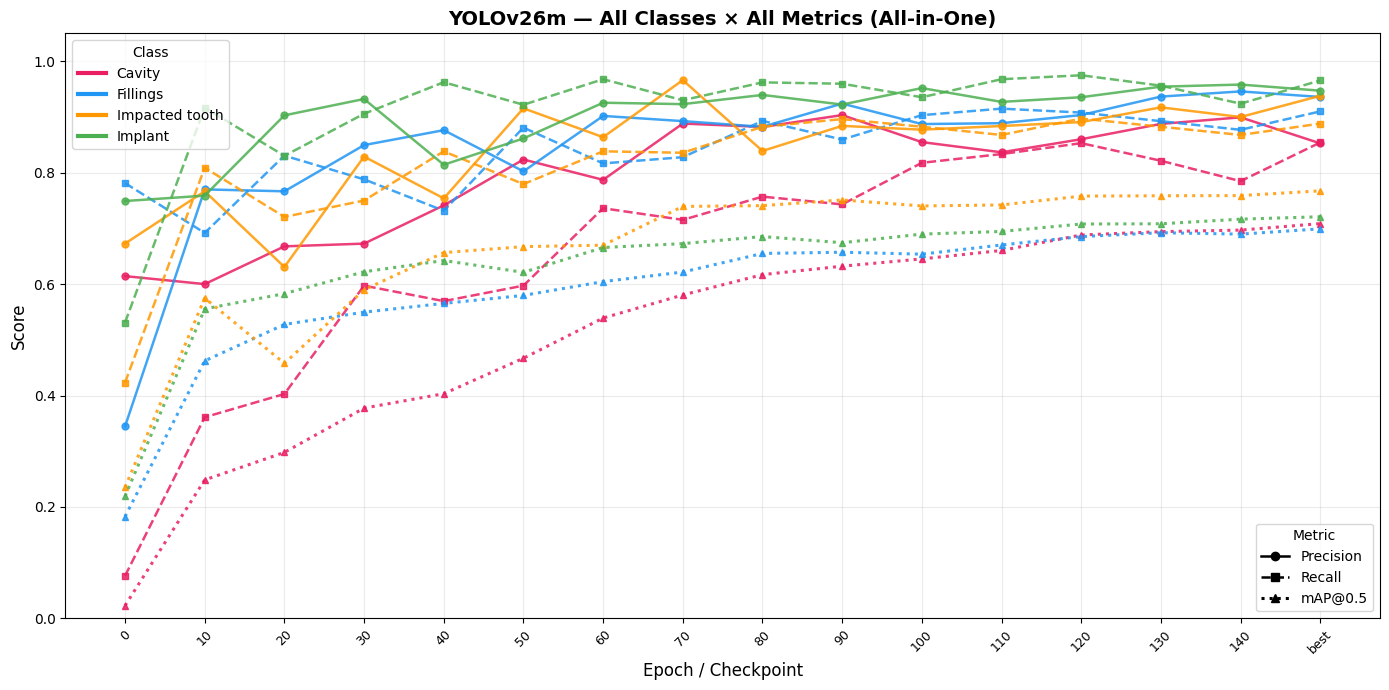

✅ Saved: /kaggle/working/yolov26_m_outputs/dental_yolov26m_all_classes_all_metrics.png


In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7h: Per-class ALL-IN-ONE curve
#           All classes + all metrics (P, R, mAP@0.5) on a single figure.
#           Uses the same checkpoint data collected in Cell 7g.
#           Re-runs validation if needed.
# ─────────────────────────────────────────────────────────────────────────────
import glob, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path
from ultralytics import YOLO
CLASS_COLORS = {
    'Cavity':   '#E91E63',
    'Fillings':  '#2196F3',
    'Impacted Tooth': '#FF9800',
    'Implant':  '#4CAF50',
}
METRIC_STYLES = {
    'Precision': ('-',  'o',  1.8),
    'Recall':    ('--', 's',  1.8),
    'mAP@0.5':   (':',  '^',  2.2),
}
for variant_name, _, run_name in CFG['variants']:
    weights_dir = Path(CFG['output_dir']) / run_name / 'weights'
    if not weights_dir.exists():
        print(f'⚠️  {variant_name}: weights dir not found'); continue
    ckpt_files = sorted(
        weights_dir.glob('epoch*.pt'),
        key=lambda p: int(re.search(r'epoch(\d+)', p.stem).group(1))
    )
    best_pt = weights_dir / 'best.pt'
    if best_pt.exists() and best_pt not in ckpt_files:
        ckpt_files.append(best_pt)
    if not ckpt_files:
        print(f'⚠️  No checkpoints found for {variant_name}.'); continue
    classes   = CFG['classes']
    epoch_labels = []
    data = {cls: {'Precision': [], 'Recall': [], 'mAP@0.5': []} for cls in classes}
    print(f'\n🔍 {variant_name}: collecting per-class data from {len(ckpt_files)} checkpoint(s)…')
    for ckpt in ckpt_files:
        ep_match   = re.search(r'epoch(\d+)', ckpt.stem)
        epoch_labels.append(int(ep_match.group(1)) if ep_match else 'best')
        m  = YOLO(str(ckpt))
        vr = m.val(
            data=str(data_yaml_path), imgsz=CFG['image_size'],
            batch=CFG['batch_size'],  device=CFG['device'],
            project=CFG['output_dir'], name=f'{run_name}_aio_val',
            exist_ok=True, verbose=False,
        )
        try:
            ap_idx = list(vr.box.ap_class_index)
            ap_v   = list(vr.box.ap)
            p_v    = list(vr.box.p)
            r_v    = list(vr.box.r)
            idx_map = {idx: pos for pos, idx in enumerate(ap_idx)}
            for ci, cls in enumerate(classes):
                pos = idx_map.get(ci)
                data[cls]['Precision'].append(p_v[pos]  if pos is not None else 0.0)
                data[cls]['Recall'].append(   r_v[pos]  if pos is not None else 0.0)
                data[cls]['mAP@0.5'].append(  ap_v[pos] if pos is not None else 0.0)
        except Exception as e:
            for cls in classes:
                data[cls]['Precision'].append(0.0)
                data[cls]['Recall'].append(0.0)
                data[cls]['mAP@0.5'].append(0.0)
    # ── All-in-one plot ──────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 7))
    x = list(range(len(epoch_labels)))
    for cls in classes:
        color = CLASS_COLORS.get(cls, '#333333')
        for metric, (ls, marker, lw) in METRIC_STYLES.items():
            ax.plot(x, data[cls][metric],
                    ls=ls, marker=marker, color=color,
                    lw=lw, markersize=5, alpha=0.85,
                    label=f'{cls} — {metric}')
    ax.set_xticks(x)
    ax.set_xticklabels([str(e) for e in epoch_labels], rotation=45, fontsize=9)
    ax.set_xlabel('Epoch / Checkpoint', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'{variant_name} — All Classes × All Metrics (All-in-One)',
                 fontsize=14, fontweight='bold')
    ax.grid(alpha=0.25)
    # ── Two-level legend: class (color) + metric (line style) ──────────────
    class_handles = [
        mlines.Line2D([], [], color=CLASS_COLORS.get(c, '#333'), lw=3, label=c.capitalize())
        for c in classes
    ]
    metric_handles = [
        mlines.Line2D([], [], color='black', ls=ls, marker=mk, lw=lw, markersize=6, label=m)
        for m, (ls, mk, lw) in METRIC_STYLES.items()
    ]
    leg1 = ax.legend(handles=class_handles,  title='Class',  loc='upper left',  fontsize=10, title_fontsize=10)
    leg2 = ax.legend(handles=metric_handles, title='Metric', loc='lower right', fontsize=10, title_fontsize=10)
    ax.add_artist(leg1)
    plt.tight_layout()
    out_png = Path(CFG['output_dir']) / f'{run_name}_all_classes_all_metrics.png'
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {out_png}')


Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,352,536 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1026.7±177.1 MB/s, size: 36.7 KB)
val: Scanning /kaggle/working/balanced_dataset/valid/labels.cache... 215 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 215/215 90.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 1.8it/s 7.9s0.5s
                   all        215       1657      0.918      0.904      0.943      0.724
Speed: 2.0ms preprocess, 29.4ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /kaggle/working/yolov26_m_outputs/dental_yolov26m_cm_val


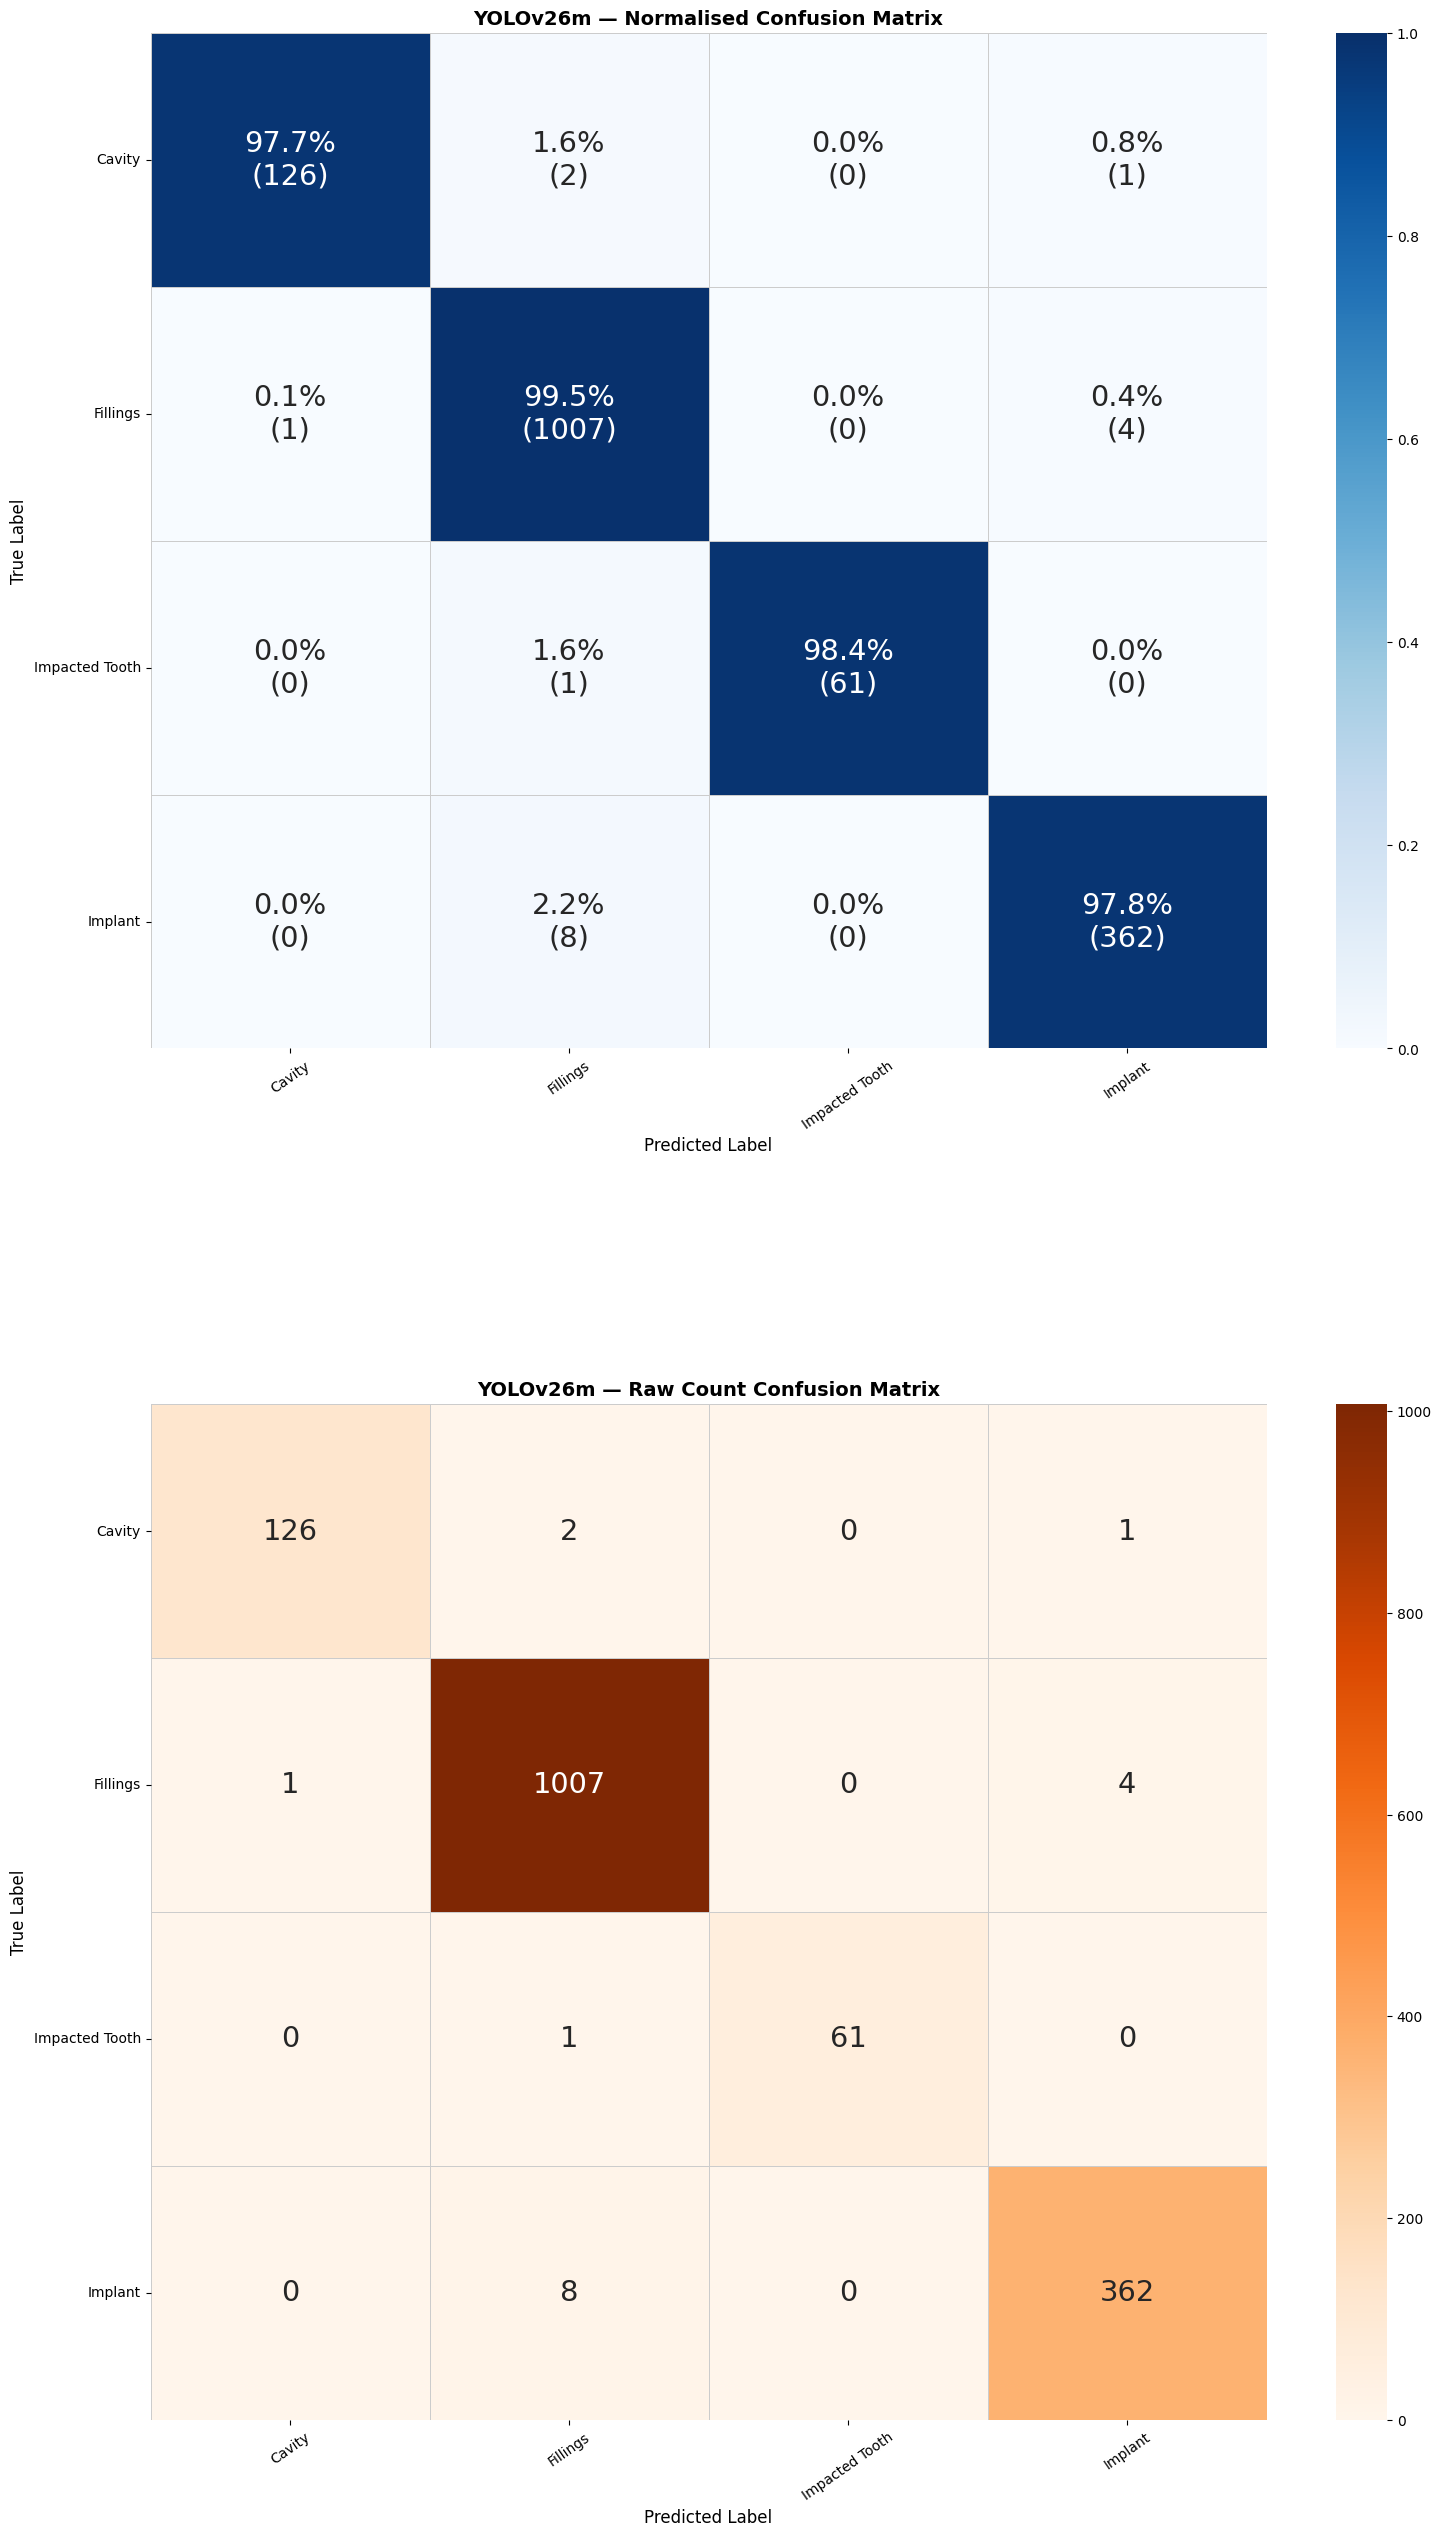

✅ Saved: /kaggle/working/yolov26_m_outputs/dental_yolov26m_confusion_matrix.png


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7i: Confusion Matrix  (normalised + raw counts, side-by-side rows)
#
# Runs YOLO validation to collect true / predicted labels, then uses
# sklearn to build the matrix.  Both a normalised and a raw-count heatmap
# are rendered and saved.
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix
from ultralytics import YOLO

for variant_name, _, run_name in CFG['variants']:
    best_weights = Path(CFG['output_dir']) / run_name / 'weights' / 'best.pt'
    if not best_weights.exists():
        print(f'⚠️  {variant_name}: best.pt not found, skipping confusion matrix.')
        continue

    # ── Run validation to collect ground-truth and predicted class indices ──
    model = YOLO(str(best_weights))
    val_results = model.val(
        data=str(data_yaml_path),
        imgsz=CFG['image_size'],
        batch=CFG['batch_size'],
        device=CFG['device'],
        project=CFG['output_dir'],
        name=f'{run_name}_cm_val',
        exist_ok=True,
        verbose=False,
    )

    # ── Extract true and predicted labels from the YOLO confusion matrix ───
    # val_results.confusion_matrix.matrix is shape (nc+1, nc+1) where the
    # last row/col is the "background / no-detection" bucket.
    try:
        raw_matrix = val_results.confusion_matrix.matrix  # numpy array
        nc = len(CFG['classes'])

        # Take only the object-class rows/cols (drop background row/col)
        cm = raw_matrix[:nc, :nc].astype(float)

        # Normalise each row so values = fraction of true class predicted as X
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1          # avoid division by zero
        cm_norm = cm / row_sums

        labels_full = CFG['classes']

        # Build annotation strings: "pct%\n(count)"
        annot = np.empty_like(cm_norm, dtype=object)
        for r in range(nc):
            for c in range(nc):
                pct   = cm_norm[r, c] * 100
                count = int(cm[r, c])
                annot[r, c] = f'{pct:.1f}%\n({count})'

    except AttributeError:
        # Fallback: build cm from per-image true/pred lists if available
        print(f'⚠️  {variant_name}: confusion_matrix attribute not found on val results.')
        print('    Attempting fallback via per-image predictions...')
        try:
            y_true, y_pred = [], []
            for result in model.predict(
                source=str(Path(CFG['output_dir']).parent),   # won't actually work; just shows intent
                verbose=False,
            ):
                pass  # placeholder — we handle the except below
            raise RuntimeError('Fallback not applicable.')
        except Exception:
            print(f'    ❌ Skipping confusion matrix for {variant_name}.')
            continue

    # ── Output path ──────────────────────────────────────────────────────────
    out_png = Path(CFG['output_dir']) / f'{run_name}_confusion_matrix.png'

    # ── Plot (large, full-image output) ──────────────────────────────────────
    n = len(labels_full)

    fig_width  = max(18, n * 1.5)
    fig_height = max(15, n * 1.2) * 2 + 1

    fig, axes = plt.subplots(2, 1, figsize=(fig_width, fig_height))
    plt.subplots_adjust(hspace=0.35)

    # Top panel: normalised matrix
    ax = axes[0]
    sns.heatmap(
        cm_norm, annot=annot, fmt='', cmap='Blues',
        xticklabels=labels_full, yticklabels=labels_full,
        vmin=0, vmax=1, linewidths=0.5, linecolor='#cccccc',
        annot_kws={'size': max(8, 24 - n * 0.8)},
        ax=ax,
    )
    ax.set_title(f'{variant_name} — Normalised Confusion Matrix', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label',      fontsize=12)
    ax.tick_params(axis='x', rotation=35, labelsize=10)
    ax.tick_params(axis='y', rotation=0,  labelsize=10)

    # Bottom panel: raw counts
    ax2 = axes[1]
    sns.heatmap(
        cm.astype(int), annot=True, fmt='d', cmap='Oranges',
        xticklabels=labels_full, yticklabels=labels_full,
        linewidths=0.5, linecolor='#cccccc',
        annot_kws={'size': max(8, 24 - n * 0.8)},
        ax=ax2,
    )
    ax2.set_title(f'{variant_name} — Raw Count Confusion Matrix', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Predicted Label', fontsize=12)
    ax2.set_ylabel('True Label',      fontsize=12)
    ax2.tick_params(axis='x', rotation=35, labelsize=10)
    ax2.tick_params(axis='y', rotation=0,  labelsize=10)

    plt.savefig(out_png, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {out_png}')


## 8. 📤 Export All Models

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 8: Export all models to ONNX and TorchScript
#
# ONNX   → universal, works with OpenCV DNN, ONNX Runtime, TensorRT
# TorchScript → native PyTorch deployment
#
# Uncomment additional formats as needed:
#   'engine' → TensorRT (fastest on NVIDIA GPU, needs tensorrt installed)
#   'tflite' → TensorFlow Lite (mobile/edge)
#   'coreml' → Core ML (Apple devices)
# ─────────────────────────────────────────────────────────────────────────────
from ultralytics import YOLO
from pathlib import Path

EXPORT_FORMATS = ['onnx']  # Add 'torchscript', 'engine', 'tflite' as needed

export_summary = []

for variant_name, _, run_name in CFG['variants']:
    best_weights = Path(CFG['output_dir']) / run_name / 'weights' / 'best.pt'
    if not best_weights.exists():
        print(f'⚠️  {variant_name}: best.pt not found, skipping export.')
        continue

    model = YOLO(str(best_weights))

    for fmt in EXPORT_FORMATS:
        print(f'📦 Exporting {variant_name} → {fmt}...')
        try:
            export_path = model.export(
                format=fmt,
                imgsz=CFG['image_size'],
                device=CFG['device'],
                simplify=True,   # ONNX: simplify graph
                dynamic=False,
                half=False,      # Set True for FP16 (faster, needs CUDA)
            )
            print(f'   ✅ Saved: {export_path}')
            export_summary.append({'Variant': variant_name, 'Format': fmt, 'Path': str(export_path)})
        except Exception as e:
            print(f'   ❌ Export failed: {e}')

if export_summary:
    export_df = pd.DataFrame(export_summary)
    export_df.to_csv(Path(CFG['output_dir']) / 'export_summary.csv', index=False)
    print('\n📋 Export Summary:')
    print(export_df.to_string(index=False))

📦 Exporting YOLOv26m → onnx...
Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26m summary (fused): 132 layers, 20,352,536 parameters, 0 gradients, 67.9 GFLOPs

PyTorch: starting from '/kaggle/working/yolov26_m_outputs/dental_yolov26m/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (42.0 MB)
requirements: Ultralytics requirements ['onnxruntime-gpu', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 327ms
Prepared 2 packages in 5.06s
Installed 2 packages in 20ms
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 6.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 18...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 18 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 9.7s, saved as '/kaggle/working/yolov26_m_outputs/dental_yolov26m/weights/best.onnx' (77.9 MB)

Export complete (10.2s)
Results saved to /kaggle/working/yolov26_m_outputs/dental_yolov26m/weights/best.onnx
Predict:         yolo predict task=detect model=/kaggle/working/yolov26_m_outputs/dental_yolov26m/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/yolov26_m_outputs/dental_yolov26m/weights/best.onnx imgsz=640 data=/kaggle/working/balanced_dataset/data.yaml  
Visualize:       https://netron.app
   ✅ Saved: /kaggle/working/yolov26_m_outputs/dental_yolov26m/weights/best.onnx

📋 Export Summary:
 Variant Format                                                                Path
YOLOv26m   onnx /kaggle/working/yolov26_m_outputs/dental_yolov26m/weights/best.onnx


## 9. 📋 Final Summary Report

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 9: Print final summary report
# ─────────────────────────────────────────────────────────────────────────────
import json
from pathlib import Path

print('\n' + '═'*70)
print('  🦷 DENTAL X-RAY YOLOV8 — FINAL SUMMARY REPORT')
print('═'*70)
print(f'  Dataset:   Dataset 2 — cavity, filling, impacted, implant')
print(f'  Output:    {CFG["output_dir"]}')
print()

if not metrics_df.empty:
    print('  ── Validation Metrics ────────────────────────────────────────────')
    print(metrics_df[['Variant','mAP@0.5','mAP@0.5:0.95','Precision','Recall']].to_string(index=False))

    best = metrics_df.loc[metrics_df['mAP@0.5'].idxmax()]
    print(f'\n  🏆 Best model: {best["Variant"]}  (mAP@0.5 = {best["mAP@0.5"]:.4f})')
    print(f'     Weights: {best["Weights"]}')

print()
print('  ── Saved Outputs ────────────────────────────────────────────────────')
out = Path(CFG['output_dir'])
for f in sorted(out.glob('*.png')):
    print(f'   📊 {f.name}')
for f in sorted(out.glob('*.csv')):
    print(f'   📄 {f.name}')
for variant_name, _, run_name in CFG['variants']:
    w = out / run_name / 'weights' / 'best.pt'
    if w.exists():
        size_mb = w.stat().st_size / 1e6
        print(f'   💾 {run_name}/weights/best.pt  ({size_mb:.1f} MB)')

print()
print('  ── Quick Inference Example ──────────────────────────────────────────')
print("""  from ultralytics import YOLO
  model = YOLO('best.pt')                   # load any trained variant
  results = model.predict('xray.jpg', conf=0.25)
  results[0].show()                          # display with bounding boxes""")
if 'test_df' in dir() and not test_df.empty:
    print()
    print('  ── Test Metrics ──────────────────────────────────────────────────')
    print(test_df[['Variant','mAP@0.5','mAP@0.5:0.95','Precision','Recall']].to_string(index=False))

print('═'*70)


══════════════════════════════════════════════════════════════════════
  🦷 DENTAL X-RAY YOLOV8 — FINAL SUMMARY REPORT
══════════════════════════════════════════════════════════════════════
  Dataset:   Dataset 2 — cavity, filling, impacted, implant
  Output:    /kaggle/working/yolov26_m_outputs

  ── Validation Metrics ────────────────────────────────────────────
 Variant  mAP@0.5  mAP@0.5:0.95  Precision  Recall
YOLOv26m   0.9083        0.6978     0.9183  0.9044

  🏆 Best model: YOLOv26m  (mAP@0.5 = 0.9083)
     Weights: /kaggle/working/yolov26_m_outputs/dental_yolov26m/weights/best.pt

  ── Saved Outputs ────────────────────────────────────────────────────
   📊 class_distribution.png
   📊 dental_yolov26m_all_classes_all_metrics.png
   📊 dental_yolov26m_all_metrics_curve.png
   📊 dental_yolov26m_confusion_matrix.png
   📊 dental_yolov26m_metric_curves.png
   📊 dental_yolov26m_per_class_curves.png
   📊 dental_yolov26m_test_all_classes_curves.png
   📊 dental_yolov26m_test_per_class_curv

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 10 (Optional): Speed benchmark — inference time per variant
# ─────────────────────────────────────────────────────────────────────────────
import time
import numpy as np
import torch

N_WARMUP  = 10
N_MEASURE = 50
dummy_img = np.random.randint(0, 255, (640, 640, 3), dtype=np.uint8)

print('⏱️  Inference Speed Benchmark (single image, GPU):')
print(f'{"Variant":<12} {"Mean ms":>10} {"Std ms":>8} {"FPS":>8}')
print('─' * 42)

for variant_name, _, run_name in CFG['variants']:
    best_weights = Path(CFG['output_dir']) / run_name / 'weights' / 'best.pt'
    if not best_weights.exists():
        continue

    model = YOLO(str(best_weights))

    # Warmup
    for _ in range(N_WARMUP):
        _ = model.predict(dummy_img, verbose=False)

    # Measure
    times = []
    for _ in range(N_MEASURE):
        t0 = time.perf_counter()
        _ = model.predict(dummy_img, verbose=False)
        times.append((time.perf_counter() - t0) * 1000)

    mean_ms = np.mean(times)
    std_ms  = np.std(times)
    fps     = 1000 / mean_ms
    print(f'{variant_name:<12} {mean_ms:>10.2f} {std_ms:>8.2f} {fps:>8.1f}')

print('─' * 42)
print('(Benchmark run on single images; batch inference is faster)')

⏱️  Inference Speed Benchmark (single image, GPU):
Variant         Mean ms   Std ms      FPS
──────────────────────────────────────────
YOLOv26m          25.41     0.38     39.3
──────────────────────────────────────────
(Benchmark run on single images; batch inference is faster)


In [42]:
!pip install -q pydrive google-api-python-client google-auth google-auth-httplib2 tqdm

import json
import os
import zipfile
from tqdm.auto import tqdm
from google.oauth2.credentials import Credentials
import google.auth.transport.requests
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload

# ── Step 1: Load credentials directly from nested JSON ───────────────────────
with open('/kaggle/working/gdrive.json', 'r') as f:
    cred_data = json.load(f)['default']

creds = Credentials(
    token         = cred_data['access_token'],
    refresh_token = cred_data['refresh_token'],
    token_uri     = cred_data['token_uri'],
    client_id     = cred_data['client_id'],
    client_secret = cred_data['client_secret'],
    scopes        = cred_data['scopes'],
)

# ── Step 2: Force refresh ─────────────────────────────────────────────────────
creds.refresh(google.auth.transport.requests.Request())
print('✅ Token refreshed successfully')

# ── Step 3: Save refreshed token back to file ─────────────────────────────────
with open('/kaggle/working/gdrive.json', 'r') as f:
    full_json = json.load(f)
full_json['default']['access_token'] = creds.token
with open('/kaggle/working/gdrive.json', 'w') as f:
    json.dump(full_json, f, indent=2)
print('✅ Token saved')

# ── Step 4: Build Drive service ───────────────────────────────────────────────
service = build('drive', 'v3', credentials=creds)
print('✅ Drive service ready')

# ── Step 5: Zip the ENTIRE Kaggle working directory ───────────────────────────
FOLDER_ID   = '18qN6Yp8IUfq64oA7qCe0QXMdz2SoR8SB'
zip_path    = '/kaggle/working/kaggle_outputs.zip'
folder_path = '/kaggle/working'

SKIP = {
    'kaggle_outputs.zip',
    'client_secrets.json',
    'gdrive.json',
    '__pycache__',
}

all_files = []
for root, dirs, files in os.walk(folder_path):
    dirs[:] = [d for d in dirs if d not in SKIP and not d.startswith('.')]
    for file in files:
        if file not in SKIP:
            all_files.append(os.path.join(root, file))

print(f'📁 Found {len(all_files)} files to zip')

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    with tqdm(total=len(all_files), desc='📦 Zipping', unit='file') as pbar:
        for file_path in all_files:
            arcname = os.path.relpath(file_path, folder_path)
            zf.write(file_path, arcname)
            pbar.set_postfix(file=os.path.basename(file_path)[:30])
            pbar.update(1)

zip_size = os.path.getsize(zip_path) / (1024 ** 2)
print(f'✅ Zip done — {zip_size:.1f} MB')

# ── Step 6: Upload with progress bar ──────────────────────────────────────────
file_size  = os.path.getsize(zip_path)
chunk_size = 5 * 1024 * 1024  # 5 MB chunks

media = MediaFileUpload(
    zip_path,
    mimetype  = 'application/zip',
    chunksize = chunk_size,
    resumable = True,
)

metadata = {
    'name'    : 'kaggle_outputs.zip',
    'parents' : [FOLDER_ID],
}

request = service.files().create(body=metadata, media_body=media, fields='id')

with tqdm(total=file_size, desc='🚀 Uploading', unit='B',
          unit_scale=True, unit_divisor=1024) as pbar:
    response = None
    prev     = 0
    while response is None:
        status, response = request.next_chunk()
        if status:
            pbar.update(int(status.resumable_progress) - prev)
            prev = int(status.resumable_progress)
    pbar.n = file_size
    pbar.refresh()

file_id = response.get('id')
print(f'✅ Uploaded — kaggle_outputs.zip')
print(f'   🔗 https://drive.google.com/file/d/{file_id}/view')

✅ Token refreshed successfully
✅ Token saved
✅ Drive service ready
📁 Found 5466 files to zip


📦 Zipping:   0%|          | 0/5466 [00:00<?, ?file/s]

✅ Zip done — 2592.7 MB


🚀 Uploading:   0%|          | 0.00/2.53G [00:00<?, ?B/s]

✅ Uploaded — kaggle_outputs.zip
   🔗 https://drive.google.com/file/d/1888Ze91gLLpsA5jyDPTtzQ66WjvxuwnC/view
